As a developer of games for mobile devices, TZ gaming has achieved strong growth of its customer base. A prominent source of new customers has come from ads displayed through the Vneta ad-network. A mobile-ad network is a technology platform that serves as a broker between (1) app developers (or publishers) looking to sell ad space and (2) a group of advertisers.
App developers sell “impressions”, i.e., a space where an ad can be shown, through the Vneta network to companies such as TZ gaming looking to advertise to app users. Vneta acts as a broker for 50-60 millions impressions/ads per day.
TZ gaming uses ads to appeal to prospective customers for their games. They generally use short (15 sec) video ads that help to emphasize the dynamic nature of the games. In the past, TZ has been able to, approximately, break-even on ad-spend with Vneta when calculating the benefits that can be directly attributed to ad click-through. Many senior executives at TZ believe that there are additional, longer-term, benefits from these ads such as brand awareness, etc. that are harder to quantify.
Currently, TZ has access to very limited data from Vneta. Matt Huateng, the CEO of TZ gaming, is intrigued by the potential for data science to enhance the efficiency of targeted advertising on mobile devices. Specifically, two options are under consideration: (1) Buy access to additional data from Vneta and use TZ’s analytics team to build targeting models or (2) Subscribe to Vneta’s analytics consultancy service, which provides impression-level click-through rate predictions based on Vneta’s proprietary data and algorithms.
Vneta has shared behavioral information linked to 115,488 recent impressions used to show TZ ads and has also provided a set or predictions based on their own (proprietary) algorithm. Matt is unsure if the consulting services offered by Vneta will be worth the money for future ad campaigns and has asked you to do some initial analyses on the provided data and compare the generated predictions to Vneta’s recommendations. The following targeting options will be evaluated to determine the best path forward.

# TZ Gaming: Optimal Targeting of Mobile Ads

In [1]:
import os

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyrsm as rsm
import seaborn as sns

# increase plot resolution
# mpl.rcParams["figure.dpi"] = 200

In [2]:
# # if your pyrsm version is not 1.1.0 install in a
# # terminal using: pip install --user pyrsm --upgrade
# rsm.__version__

In [3]:
# loading data tz_gaming.parquet
tz_gaming = pd.read_parquet("data/tz_gaming.parquet")

In [4]:
tz_gaming.head()

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,ctrua,imput,clut,ctrut,imppat,clpat,ctrpat,rnd,pred_vneta,id
0,train,I7,no,9,9,app8,ios,439,2,0.455581,...,0.000000,25,0,0.000000,71,1,1.408451,-1.207066,0.003961,id247135
1,train,I23,no,15,15,app1,ios,64,0,0.000000,...,0.000000,7,0,0.000000,67312,1069,1.588127,0.277429,0.003961,id245079
2,train,I28,no,12,12,app5,ios,80,0,0.000000,...,6.578947,94,0,0.000000,331,1,0.302115,1.084441,0.003961,id927245
3,train,I30,no,19,19,app1,ios,25,0,0.000000,...,0.000000,19,0,0.000000,71114,1001,1.407599,-2.345698,0.018965,id922188
4,train,I35,no,24,24,app1,android,3834,29,0.756390,...,0.689655,329,4,1.215805,183852,2317,1.260253,0.429125,0.003961,id355833


In [5]:
tz_gaming.training.value_counts(True)

training
train    0.757958
test     0.242042
Name: proportion, dtype: float64

In [6]:
tz_gaming.training.value_counts(False)

training
train    87535
test     27953
Name: count, dtype: int64

In [7]:
tz_gaming.click.value_counts(dropna=False) # keep the na in data

click
no     114443
yes      1045
Name: count, dtype: int64

In [8]:
tz_gaming.click.isna().value_counts()

click
False    115488
Name: count, dtype: int64

In [9]:
q = pd.crosstab(
    index=tz_gaming.click[tz_gaming.training == "train"],
    columns = "response rate",
    normalize = "columns",
)
q

col_0,response rate
click,
yes,0.008842
no,0.991158


In [10]:
a = pd.pivot_table(
    tz_gaming, #[tz_gaming.training == "train"],
    values = "impua",
    index = "click", 
    aggfunc= {"impua": ["count", "mean", "std"]},
    observed = False
)
a

,count,mean,std
click,,,
yes,1045,18.548325,33.248524
no,114443,43.567234,69.440048


In [11]:
tz_gaming["click_yes"] = rsm.ifelse(tz_gaming["click"] == "yes", 1, rsm.ifelse(tz_gaming["click"] == "no", 0, np.nan))

In [12]:
# tz_gaming["click_yes"] = tz_gaming["click"].map({"yes": 1, "no": 0, np.nan: np.nan})
# tz_gaming["click_yes"] = tz_gaming["click_yes"].astype("float64")

## Part I: Logistic regression (10 points)

> Note: For the following questions, use only the "training" sample of impressions (i.e., 87,535 rows where "training == 'train'").

a. Estimate a logistic regression model using `click` as the response variable (target) and the following as explanatory variables (features). The model should predict the probability that `click` is equal to "yes" (2 points):

`time_fct, app, mobile_os, impua, clua, ctrua`

In [13]:
tz_gaming[(tz_gaming.training == "train")]

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,imput,clut,ctrut,imppat,clpat,ctrpat,rnd,pred_vneta,id,click_yes
0,train,I7,no,9,9,app8,ios,439,2,0.455581,...,25,0,0.000000,71,1,1.408451,-1.207066,0.003961,id247135,0.0
1,train,I23,no,15,15,app1,ios,64,0,0.000000,...,7,0,0.000000,67312,1069,1.588127,0.277429,0.003961,id245079,0.0
2,train,I28,no,12,12,app5,ios,80,0,0.000000,...,94,0,0.000000,331,1,0.302115,1.084441,0.003961,id927245,0.0
3,train,I30,no,19,19,app1,ios,25,0,0.000000,...,19,0,0.000000,71114,1001,1.407599,-2.345698,0.018965,id922188,0.0
4,train,I35,no,24,24,app1,android,3834,29,0.756390,...,329,4,1.215805,183852,2317,1.260253,0.429125,0.003961,id355833,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87530,train,I299985,no,11,11,app2,android,1181,0,0.000000,...,55,0,0.000000,9625,14,0.145455,-0.249031,0.003961,id565693,0.0
87531,train,I299986,no,10,10,app33,ios,1885,0,0.000000,...,374,0,0.000000,658,1,0.151976,0.770718,0.003961,id222657,0.0
87532,train,I299990,no,1,1,app45,ios,8,0,0.000000,...,15,0,0.000000,166,7,4.216867,0.181559,0.018965,id340594,0.0
87533,train,I299991,no,8,8,app1,ios,113,2,1.769912,...,0,0,0.000000,14245,158,1.109161,-1.263831,0.003961,id634151,0.0


In [14]:
clf = rsm.model.logistic(
    data = {"tz_gaming test": tz_gaming[(tz_gaming.training == "train")]}, 
    rvar = "click", 
    lev = "yes", 
    evar = ["time_fct", "app", "mobile_os", "impua", "clua", "ctrua"]
)
clf.summary(main = True, fit = False)

Logistic regression (GLM)
Data                 : tz_gaming test
Response variable    : click
Level                : yes
Explanatory variables: time_fct, app, mobile_os, impua, clua, ctrua
Null hyp.: There is no effect of x on click
Alt. hyp.: There is an effect of x on click

                     OR      OR%  coefficient   std.error  z.value p.value     
Intercept         0.029   -97.1%        -3.53       0.197  -17.936  < .001  ***
time_fct[2]       0.622   -37.8%        -0.47       0.321   -1.478   0.139     
time_fct[3]       0.718   -28.2%        -0.33       0.454   -0.730   0.466     
time_fct[4]       0.000  -100.0%       -23.54   42007.161   -0.001     1.0     
time_fct[5]       0.000  -100.0%       -23.72   55229.970   -0.000     1.0     
time_fct[6]       0.349   -65.1%        -1.05       1.021   -1.030   0.303     
time_fct[7]       1.221    22.1%         0.20       0.426    0.468    0.64     
time_fct[8]       1.104    10.4%         0.10       0.296    0.335   0.737     
tim

In [15]:
clf.summary(main = False, fit = True)


Pseudo R-squared (McFadden): 0.109
Pseudo R-squared (McFadden adjusted): 0.092
Area under the RO Curve (AUC): 0.792
Log-likelihood: -3946.072, AIC: 8046.145, BIC: 8768.389
Chi-squared: 968.279, df(76), p.value < 0.001 
Nr obs: 87,535



b. Summarize and interpret the logistic regression results. Which of these explanatory variables are statistically significant? Which variables are most important? Make sure your model evaluation includes (1) an interpretation of the Permutation importance and Prediction plots for the explanatory variables `mobile_os`, `impua`, `clua`, and `ctrua` and (2) an evaluation of the model as a whole using Pseudo R-squared and the Chi-square test (5 points).

Within the app variable, app[app33], app[app31], app[app29], app[app27], app[app23], app[app21], app[app18], app[app14], app[app13], app[app6], app[app4], and app[app2] were statistically significant. Along with those, the 
intercept, mobile_os[ios], impua, clua, and ctrua are also statistically significant.  

app[app23] and app[app29] suggest significant positive effects on clicks based on their OR values, which are +211.1% and +163.4%.


the pseudo R-squared is 0.109, which is not a very good model since it is on the lower end. This means that 10.9% of the variation explained by the model.

The chi-square test has a p-value of less than 0.001, which is statistically significant. This model is slightly better than the "worst case" model or null model. There is significant association between the variables.


AUC near 0.8 indicates good model discrimination between clicked and non-clicked cases.  the model can distinguish between clicks (yes) and no-clicks fairly well.

This model overall is headed in the right direction. It shows moderate predictive power, but there is room for improvement.

mobile_os: Android users are most likely to click on an ad at 0.012 followed by other systems, and ios users are the least likely to to click on an ad at 0.006. Mobile_os is a good indicator of whether a user will click on an ad. This suggests that users of different operating systems exhibit significantly different behaviors.

impua: as the number of past impressions of the tz ad across all apps increases, the probability of a click decreases. It is following an exponential decay pattern. impua is a strpong influence of whether a user will click on an ad.

clua: as the number of past impressions of the tz ad clicked across all apps increases, the probability of a click increases.  As clua increases, the likelihood of the outcome slightly increases, but the effect size is relatively small compared to impua or mobile_os

ctrua: as the past clickthrough rate of the tz ad by the user across all apps increases, the probablity only marginally increases. It does not have much effect. its permutation importance is also very low, suggesting it is not a key factor in the model.

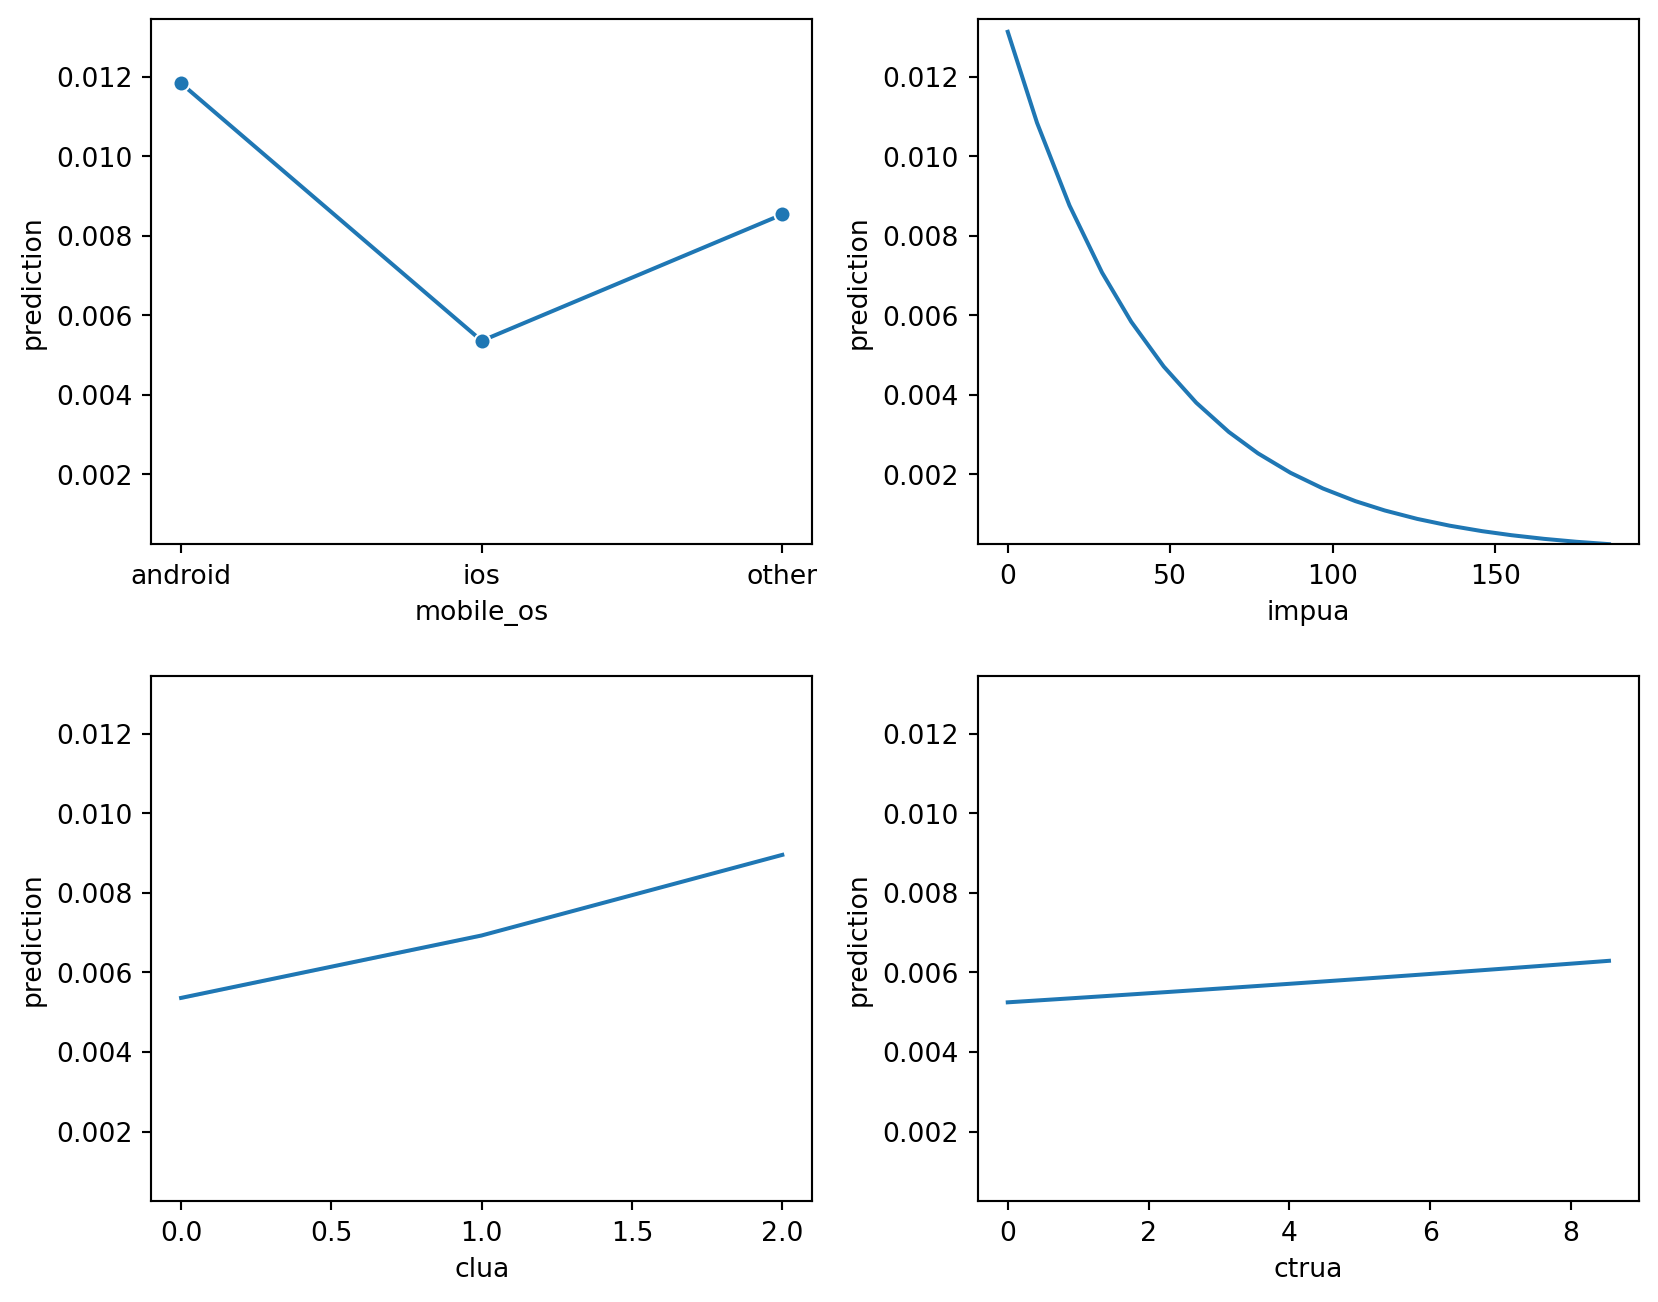

In [16]:
clf.plot("pred", excl = ["time_fct", "app"])

apps is the most important variable in the model at 0.14, but this does not tell us if it is a positive or negative effect. apps is a important feature in the performance of the model as shuffling it will resuce accuracy by 14%. impua is also a another important variable that is crucial to the performance of the model. mobile_os does not have much influence in the performance of the model. clua followed by ctrua is the least important variable in this model as it has little to no impact. 

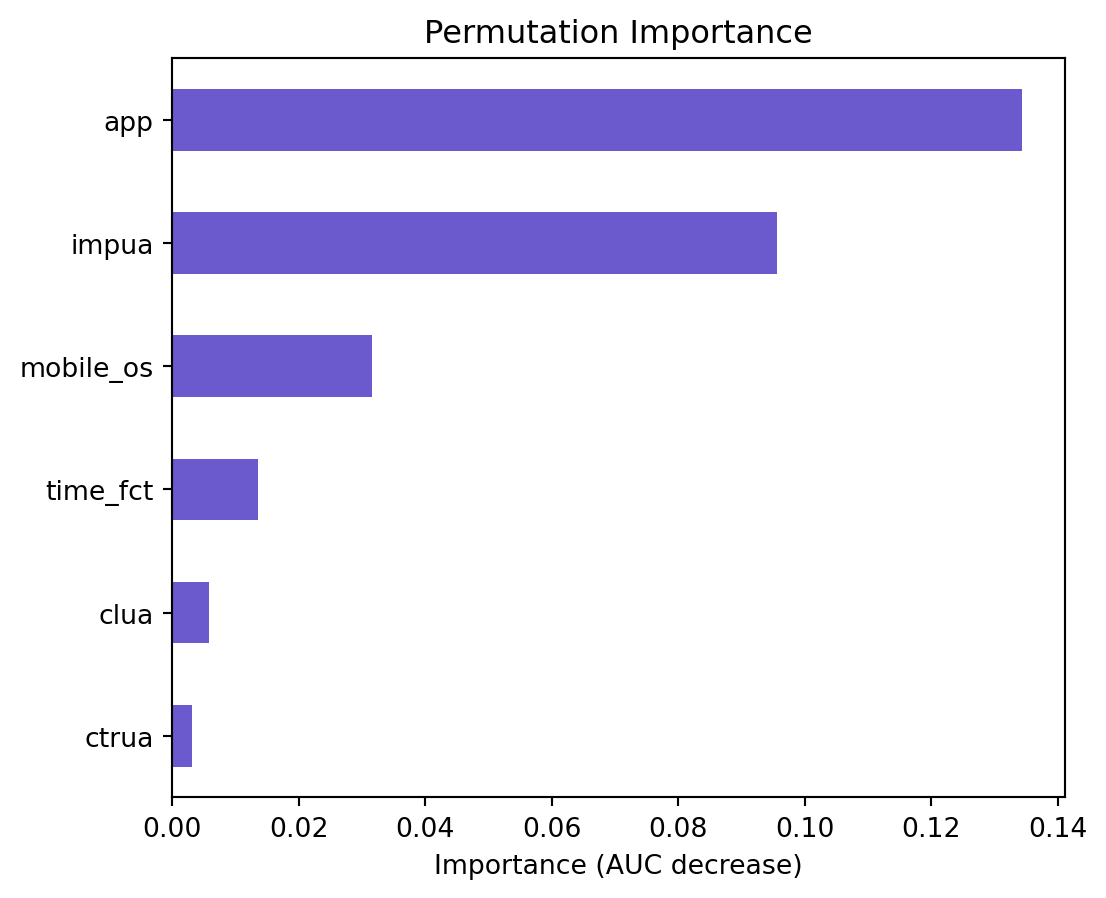

In [17]:
clf.plot("vimp", data = tz_gaming[(tz_gaming.training == "train")])

c. Predict the probability of a click (2 points)

The estimated logistic regression model can predict the probability of `click == "yes"`. Create a new variable `pred_logit` with the predicted click probabilities for each impression. Make sure to generate predictions for all rows in both the training and test data.

In [18]:
tz_gaming["pred_logit"] = clf.predict(data = tz_gaming)["prediction"]
tz_gaming

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,clut,ctrut,imppat,clpat,ctrpat,rnd,pred_vneta,id,click_yes,pred_logit
0,train,I7,no,9,9,app8,ios,439,2,0.455581,...,0,0.000000,71,1,1.408451,-1.207066,0.003961,id247135,0.0,3.382977e-13
1,train,I23,no,15,15,app1,ios,64,0,0.000000,...,0,0.000000,67312,1069,1.588127,0.277429,0.003961,id245079,0.0,1.156355e-02
2,train,I28,no,12,12,app5,ios,80,0,0.000000,...,0,0.000000,331,1,0.302115,1.084441,0.003961,id927245,0.0,2.655311e-03
3,train,I30,no,19,19,app1,ios,25,0,0.000000,...,0,0.000000,71114,1001,1.407599,-2.345698,0.018965,id922188,0.0,1.349420e-02
4,train,I35,no,24,24,app1,android,3834,29,0.756390,...,4,1.215805,183852,2317,1.260253,0.429125,0.003961,id355833,0.0,1.868222e-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,test,I399982,no,21,21,app2,ios,2110,0,0.000000,...,0,0.000000,23216,19,0.081840,-1.852059,0.003961,id847352,0.0,1.093091e-03
115484,test,I399986,no,17,17,app14,android,291,1,0.343643,...,1,1.351351,3665,14,0.381992,-0.296415,0.003961,id457437,0.0,3.609483e-03
115485,test,I399991,no,23,23,app1,android,364,3,0.824176,...,0,0.000000,173353,2292,1.322158,0.099201,0.003961,id792352,0.0,2.052670e-02
115486,test,I399992,no,20,20,app6,android,59,2,3.389831,...,1,2.702703,3474,53,1.525619,-0.186421,0.050679,id115678,0.0,2.192207e-02


d. Estimate a logistic regression with `click` as the response variable and `rnd` as the **only** explanatory variable. As before, the model should be estimated on the training sample (i.e., "training == 'train'"). Create a new variable `pred_rnd` with the predicted click-through probabilities (1 point).

In [19]:
clf_rnd = rsm.model.logistic(
    data = {"tz_gaming test": tz_gaming[(tz_gaming.training == "train")]}, 
    rvar = "click", 
    lev = "yes", 
    evar = "rnd"
)

clf_rnd.summary()

Logistic regression (GLM)
Data                 : tz_gaming test
Response variable    : click
Level                : yes
Explanatory variables: rnd
Null hyp.: There is no effect of x on click
Alt. hyp.: There is an effect of x on click

              OR     OR%  coefficient  std.error  z.value p.value     
Intercept  0.009  -99.1%        -4.72      0.036 -130.657  < .001  ***
rnd        0.965   -3.5%        -0.04      0.036   -0.986   0.324     

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.0
Pseudo R-squared (McFadden adjusted): -0.0
Area under the RO Curve (AUC): 0.513
Log-likelihood: -4429.726, AIC: 8863.451, BIC: 8882.211
Chi-squared: 0.972, df(1), p.value 0.324 
Nr obs: 87,535


In [20]:
tz_gaming["pred_rnd"] = clf_rnd.predict(data = tz_gaming)["prediction"]
tz_gaming

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,ctrut,imppat,clpat,ctrpat,rnd,pred_vneta,id,click_yes,pred_logit,pred_rnd
0,train,I7,no,9,9,app8,ios,439,2,0.455581,...,0.000000,71,1,1.408451,-1.207066,0.003961,id247135,0.0,3.382977e-13,0.009222
1,train,I23,no,15,15,app1,ios,64,0,0.000000,...,0.000000,67312,1069,1.588127,0.277429,0.003961,id245079,0.0,1.156355e-02,0.008751
2,train,I28,no,12,12,app5,ios,80,0,0.000000,...,0.000000,331,1,0.302115,1.084441,0.003961,id927245,0.0,2.655311e-03,0.008505
3,train,I30,no,19,19,app1,ios,25,0,0.000000,...,0.000000,71114,1001,1.407599,-2.345698,0.018965,id922188,0.0,1.349420e-02,0.009600
4,train,I35,no,24,24,app1,android,3834,29,0.756390,...,1.215805,183852,2317,1.260253,0.429125,0.003961,id355833,0.0,1.868222e-03,0.008704
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,test,I399982,no,21,21,app2,ios,2110,0,0.000000,...,0.000000,23216,19,0.081840,-1.852059,0.003961,id847352,0.0,1.093091e-03,0.009435
115484,test,I399986,no,17,17,app14,android,291,1,0.343643,...,1.351351,3665,14,0.381992,-0.296415,0.003961,id457437,0.0,3.609483e-03,0.008930
115485,test,I399991,no,23,23,app1,android,364,3,0.824176,...,0.000000,173353,2292,1.322158,0.099201,0.003961,id792352,0.0,2.052670e-02,0.008806
115486,test,I399992,no,20,20,app6,android,59,2,3.389831,...,2.702703,3474,53,1.525619,-0.186421,0.050679,id115678,0.0,2.192207e-02,0.008896


## Part II: Understanding Multicollinearity and Omitted Variable Bias (10 points)

a. Estimate a logistic regression model with `click` as the response variable and `imppat`, `clpat`, and `ctrpat` as the only explanatory variables. What is the interpretation of the Prediction plots for the explanatory variables? (2 points)

> Note: Make sure to watch the "Video: TZ gaming preview (12 min)" on Canvas before answering this questions so you fully understand what the variables represent

In [21]:
clf_mc1 = rsm.model.logistic(
    data = tz_gaming,
    rvar = "click",
    lev = "yes",
    evar = ["imppat", "clpat", "ctrpat"]
)

clf_mc1.summary(vif = True)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : click
Level                : yes
Explanatory variables: imppat, clpat, ctrpat
Null hyp.: There is no effect of x on click
Alt. hyp.: There is an effect of x on click

              OR     OR%  coefficient  std.error  z.value p.value     
Intercept  0.004  -99.6%        -5.42      0.064  -85.126  < .001  ***
imppat     1.000   -0.0%        -0.00      0.000   -5.639  < .001  ***
clpat      1.002    0.2%         0.00      0.000    6.782  < .001  ***
ctrpat     1.608   60.8%         0.48      0.030   15.918  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.036
Pseudo R-squared (McFadden adjusted): 0.036
Area under the RO Curve (AUC): 0.678
Log-likelihood: -5742.076, AIC: 11492.152, BIC: 11530.78
Chi-squared: 430.127, df(3), p.value < 0.001 
Nr obs: 115,488

Variance inflation factors:

           vif    Rsq
clpat   27.333  0.963
imppat  24.533  0.9

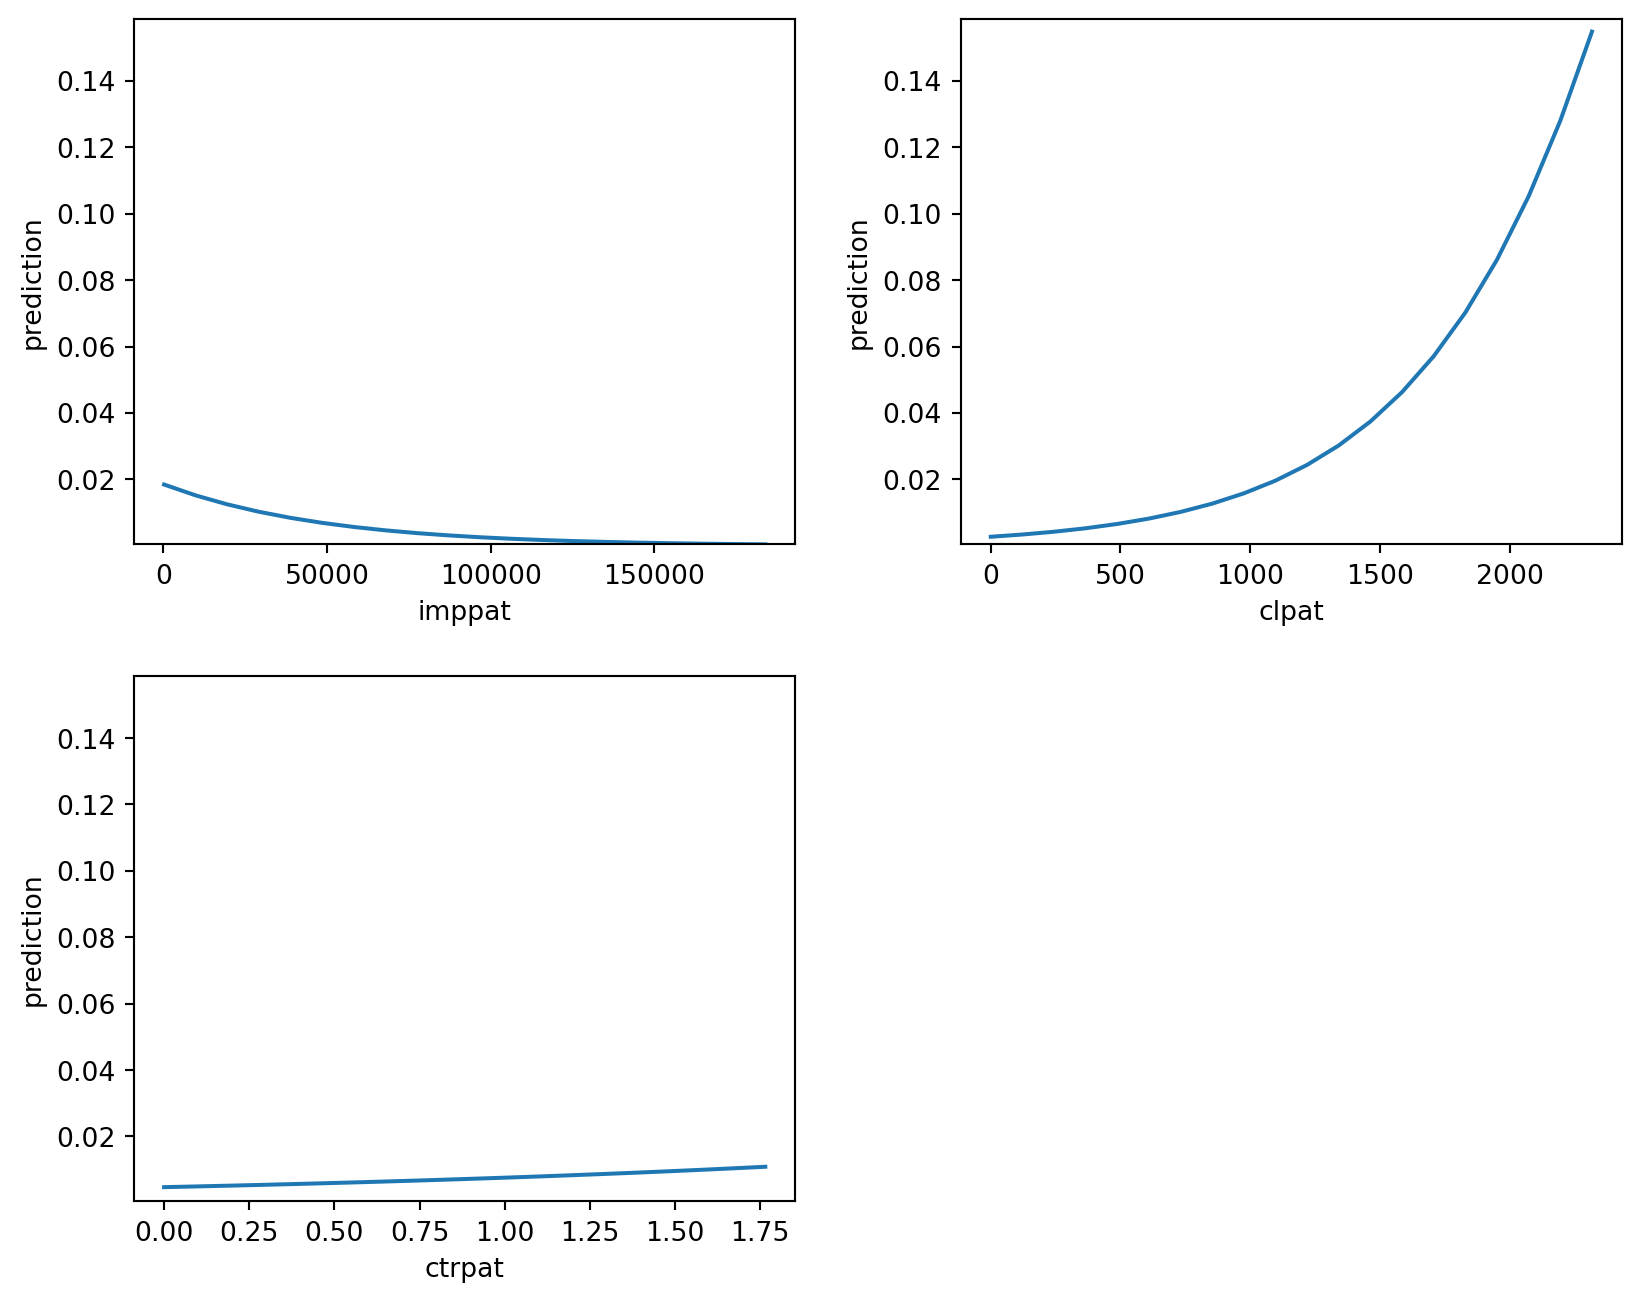

In [22]:
clf_mc1.plot("pred")

imppat: the prediction decreases as imppat increses, then flattens out at near zero. Number of past impressions that showed the TZ ad in the app in the hour
The more impressions of the TZ ad in the app in the hour, the less likely the user is to click on the ad. This is a negative relationship. This may be since the user has seen in many times and is annoyed by it so they will not click on it or ad saturation.

clpat: as clpat increases, the prediction increases exponentially. Higher click counts are strongly associated with an increased likelihood of a click. A high number of past clicks indicates strong user engagement and interest in the ad, leading to a higher likelihood of further clicks.

ctrpat: as ctrpat increases, the prediction increases slightly. A higher click-through rate leads to a slight increase in the predicted probability of a click.


b. Some of the variables in the dataset are highly correlated with each other. In particular, `imppat` and `clpat` have a very high positive correlation of 0.97. Discuss the implications of this (very) high level of collinearity and also different approaches to deal with it. What are the implications for the model and the interpretation of the Prediction plots? As part of your answer, discuss the change in the Prediction plot for `imppat` when you remove `clpat` from the model you estimated for II.a (4 points).

> Note: Assign your new model without `clpat` to a new object `clf_mc2`. Calculate VIF statistics for each explanatory variable in the model

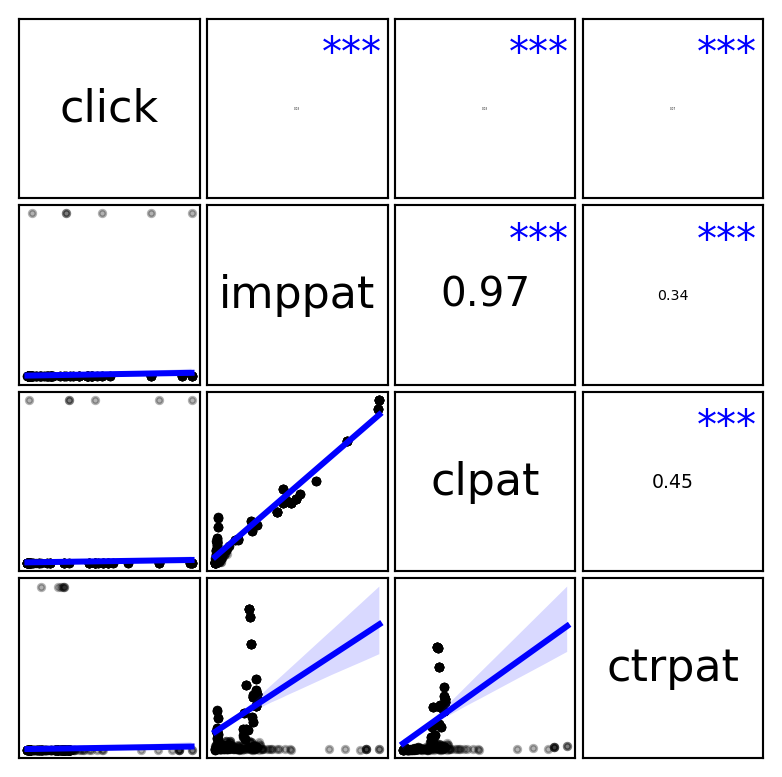

In [23]:
clf_mc1.plot('corr')

Multicollinearity in a model makes it difficult to determine the individual effect of each variable on the dependent variable. As they move in the same direction, it is difficult to determine the effect of each variable on the dependent variable. This can lead to unreliable and unstable estimates of the coefficients. small changes in the data can cause large changes in the estimated coefficients which can make is difficult to interpret the model as we don't know which explanatory variable is causing the change in the dependent variable. It may also give incorrect inforamtion about statistical significance of the variables.

To deal with multicollinearity, the best way is to remove one of the variables that are highly correlated. Another way is to combine the variables into a single variable. This can be done by creating a new variable that is a combination of the two variables. Another way is to use Lasso where the model will penalize large coefficents

In [24]:
clf_mc2 =  rsm.model.logistic(
    data = tz_gaming,
    rvar = "click",
    lev = "yes",
    evar = ["imppat", "ctrpat"]
)

clf_mc2.summary(vif=True)

Logistic regression (GLM)
Data                 : Not provided
Response variable    : click
Level                : yes
Explanatory variables: imppat, ctrpat
Null hyp.: There is no effect of x on click
Alt. hyp.: There is an effect of x on click

              OR     OR%  coefficient  std.error  z.value p.value     
Intercept  0.004  -99.6%        -5.53      0.060  -92.651  < .001  ***
imppat     1.000    0.0%         0.00      0.000    7.120  < .001  ***
ctrpat     1.728   72.8%         0.55      0.026   21.157  < .001  ***

Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Pseudo R-squared (McFadden): 0.032
Pseudo R-squared (McFadden adjusted): 0.032
Area under the RO Curve (AUC): 0.675
Log-likelihood: -5767.155, AIC: 11540.31, BIC: 11569.28
Chi-squared: 379.969, df(2), p.value < 0.001 
Nr obs: 115,488

Variance inflation factors:

          vif    Rsq
ctrpat  1.131  0.116
imppat  1.131  0.116


With the clf_mc1 model, VIF is 27.333 and 24.533 for clpat and impaat respectively. Which shows severe multicolinearity. In the new model clf_mc2, VIF is 1.131 for both ctrpat and impaat. This shows that the multicolinearity has been removed and no multicolinearity is present.

In the new model clf_mc2, imppat changes from a decreasing exponential curve to an upward sloping line showing increase. This is because the effect of clpat on imppat is removed. model attributes more importance to imppat in predicting clicks. higher impressions may indirectly imply higher clicks . ctrpat remains almost the same. The slope of the line is slightly steeper than before. Which shows that clpat did not have much effect on ctrpat.

clpat (number of past clicks) is directly related to the target variable, click. Including it captures an important aspect of user behavior that is essential for accurate predictions. The clf_mc1 model better captures the direct relationship between clicks and engagement. however, it downplays the roles of imppat and ctrpat, leading to more realistic predictions. Instead of dropping this variable, we can use other techniques like lasso to reduce the impact of multicollinearity.

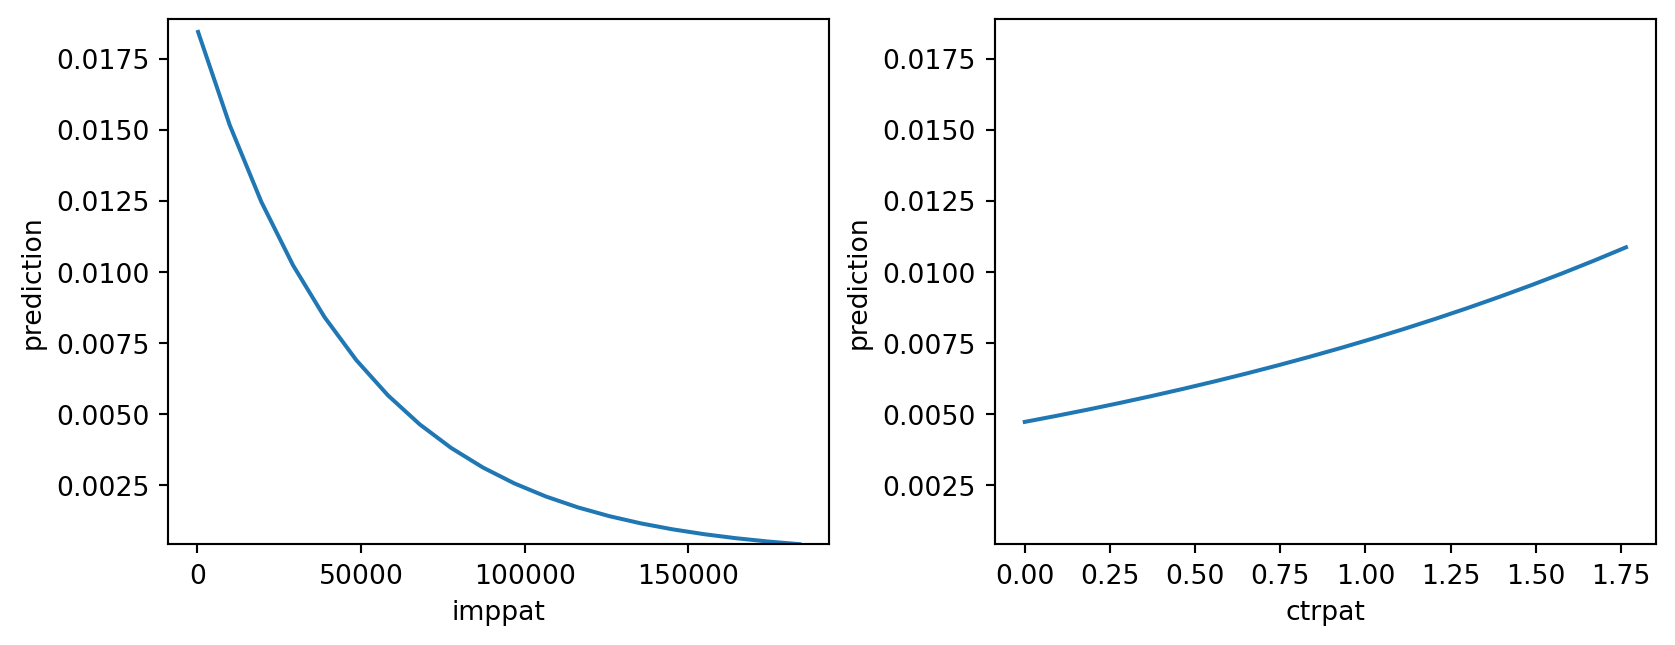

In [25]:
clf_mc1.plot("pred", excl = "clpat")

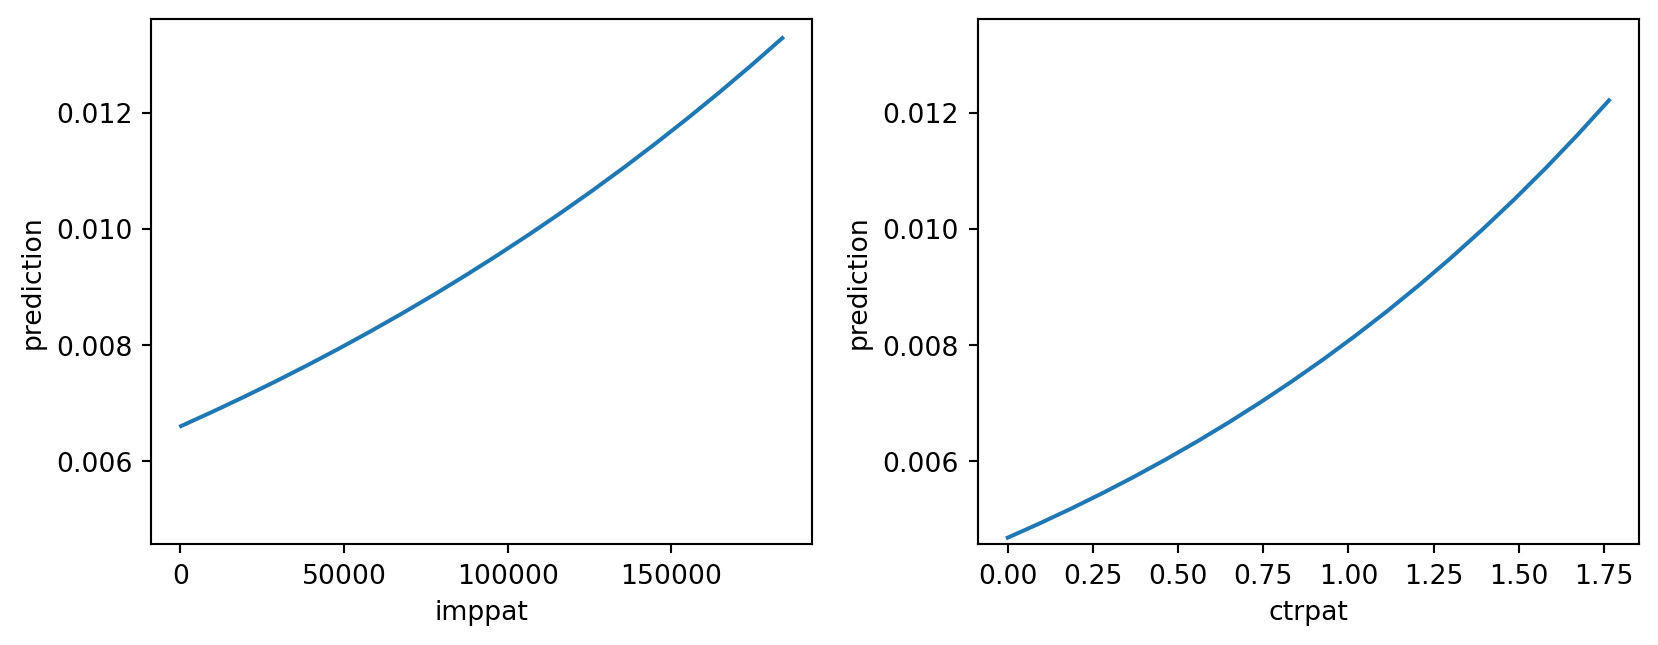

In [26]:
clf_mc2.plot("pred")

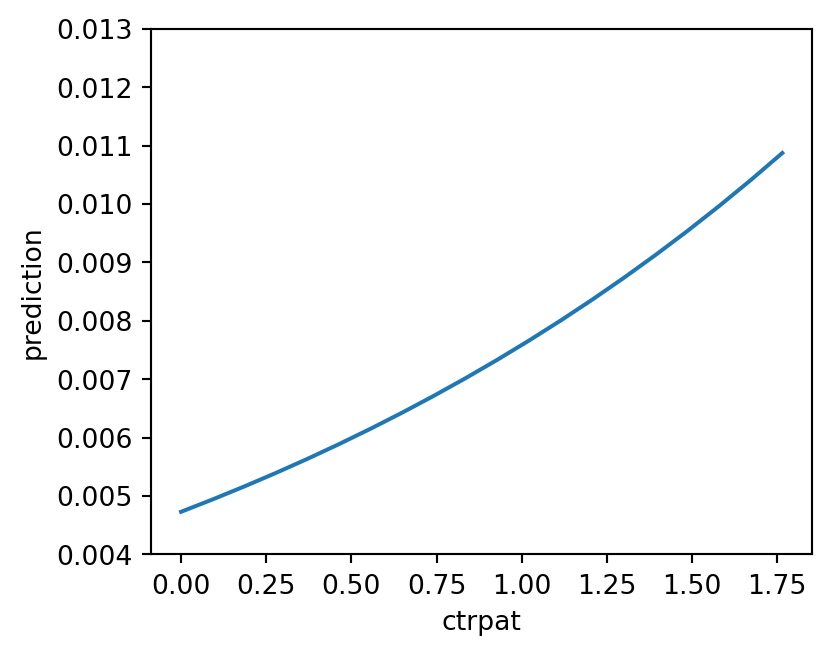

In [27]:
clf_mc1.plot("pred", excl = ["clpat", "imppat"], fix= (.004,0.013))

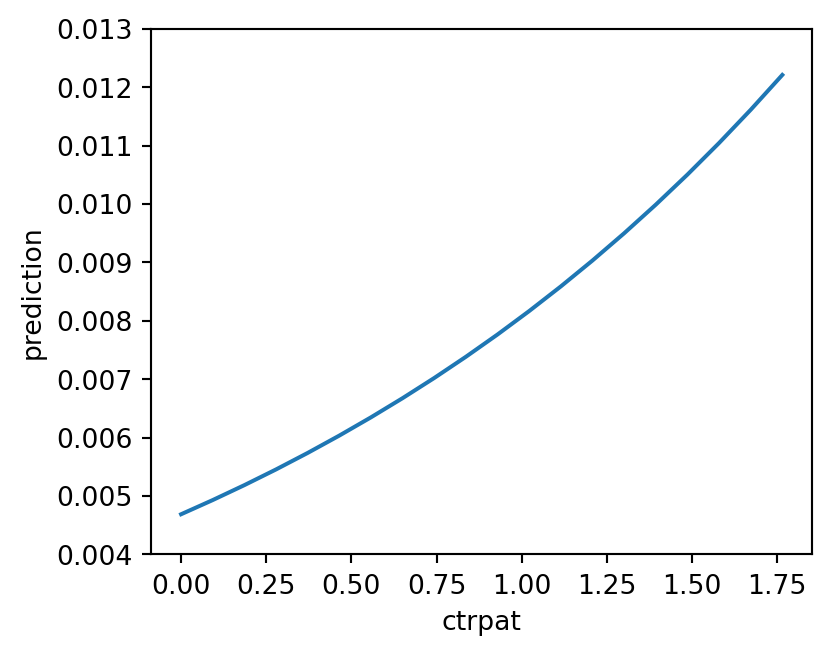

In [28]:
clf_mc2.plot("pred", excl = "imppat", fix= (.004,0.013))

c. Estimate another logistic regression model with `click` as the response variable and `time_fct`, `app`, `imppat`, `clpat`, and `ctrpat` as the explanatory variable. Why are the Prediction plots for `imppat`, `clpat`, and `ctrpat` different compared to the plots from the model you estimated in II.a? Please be specific and investigate beyond simply stating the statistical problem (4 points).

> Note: You may want to test if a (set of) coefficients are equal to 0 (or Odds-ratios are equal to 1)

We added two more explanatory variables, time_fct and app. This increased the Rsquared for the model showing that it is a better model. Since we didn't include these two variables, the effect of these two variables inflated the coefficients of the other variables, but that doesn't mean that is the actual effect. clpat after adding the time_fct and app changed. It is not as exponential as before. It went from 0 to past 0.14 in terms of prediction as clpat was increasing, but in the newer model, it only increases slightly to 0.05. That is because the effects were moved to the app and time_fct. The other two graphs look similar to the previous model. The time of day and the specific app that users are seeing the impressions are more likely to influence their click behavior as opposed to their past stats on click through rates, and previous clicks and impressions. Different users have different behaviors and habits based on the app they use. Users may get ad fatigue when they see to many. Some apps may have higher click through rates than others.

In [29]:
clf_mc3 = rsm.model.logistic(
    data = tz_gaming,
    rvar = "click",
    lev = "yes",
    evar = ["time_fct", "app", "imppat", "clpat", "ctrpat"]
)

clf_mc3.summary()

Logistic regression (GLM)
Data                 : Not provided
Response variable    : click
Level                : yes
Explanatory variables: time_fct, app, imppat, clpat, ctrpat
Null hyp.: There is no effect of x on click
Alt. hyp.: There is an effect of x on click

                 OR      OR%  coefficient  std.error  z.value p.value     
Intercept     0.013   -98.7%        -4.33      0.240  -18.052  < .001  ***
time_fct[2]   0.546   -45.4%        -0.61      0.268   -2.257   0.024    *
time_fct[3]   0.819   -18.1%        -0.20      0.348   -0.572   0.567     
time_fct[4]   0.000  -100.0%       -23.90  36246.920   -0.001   0.999     
time_fct[5]   0.250   -75.0%        -1.38      1.018   -1.360   0.174     
time_fct[6]   0.709   -29.1%        -0.34      0.607   -0.566   0.571     
time_fct[7]   1.008     0.8%         0.01      0.397    0.020   0.984     
time_fct[8]   0.943    -5.7%        -0.06      0.283   -0.207   0.836     
time_fct[9]   0.951    -4.9%        -0.05      0.259   -0.

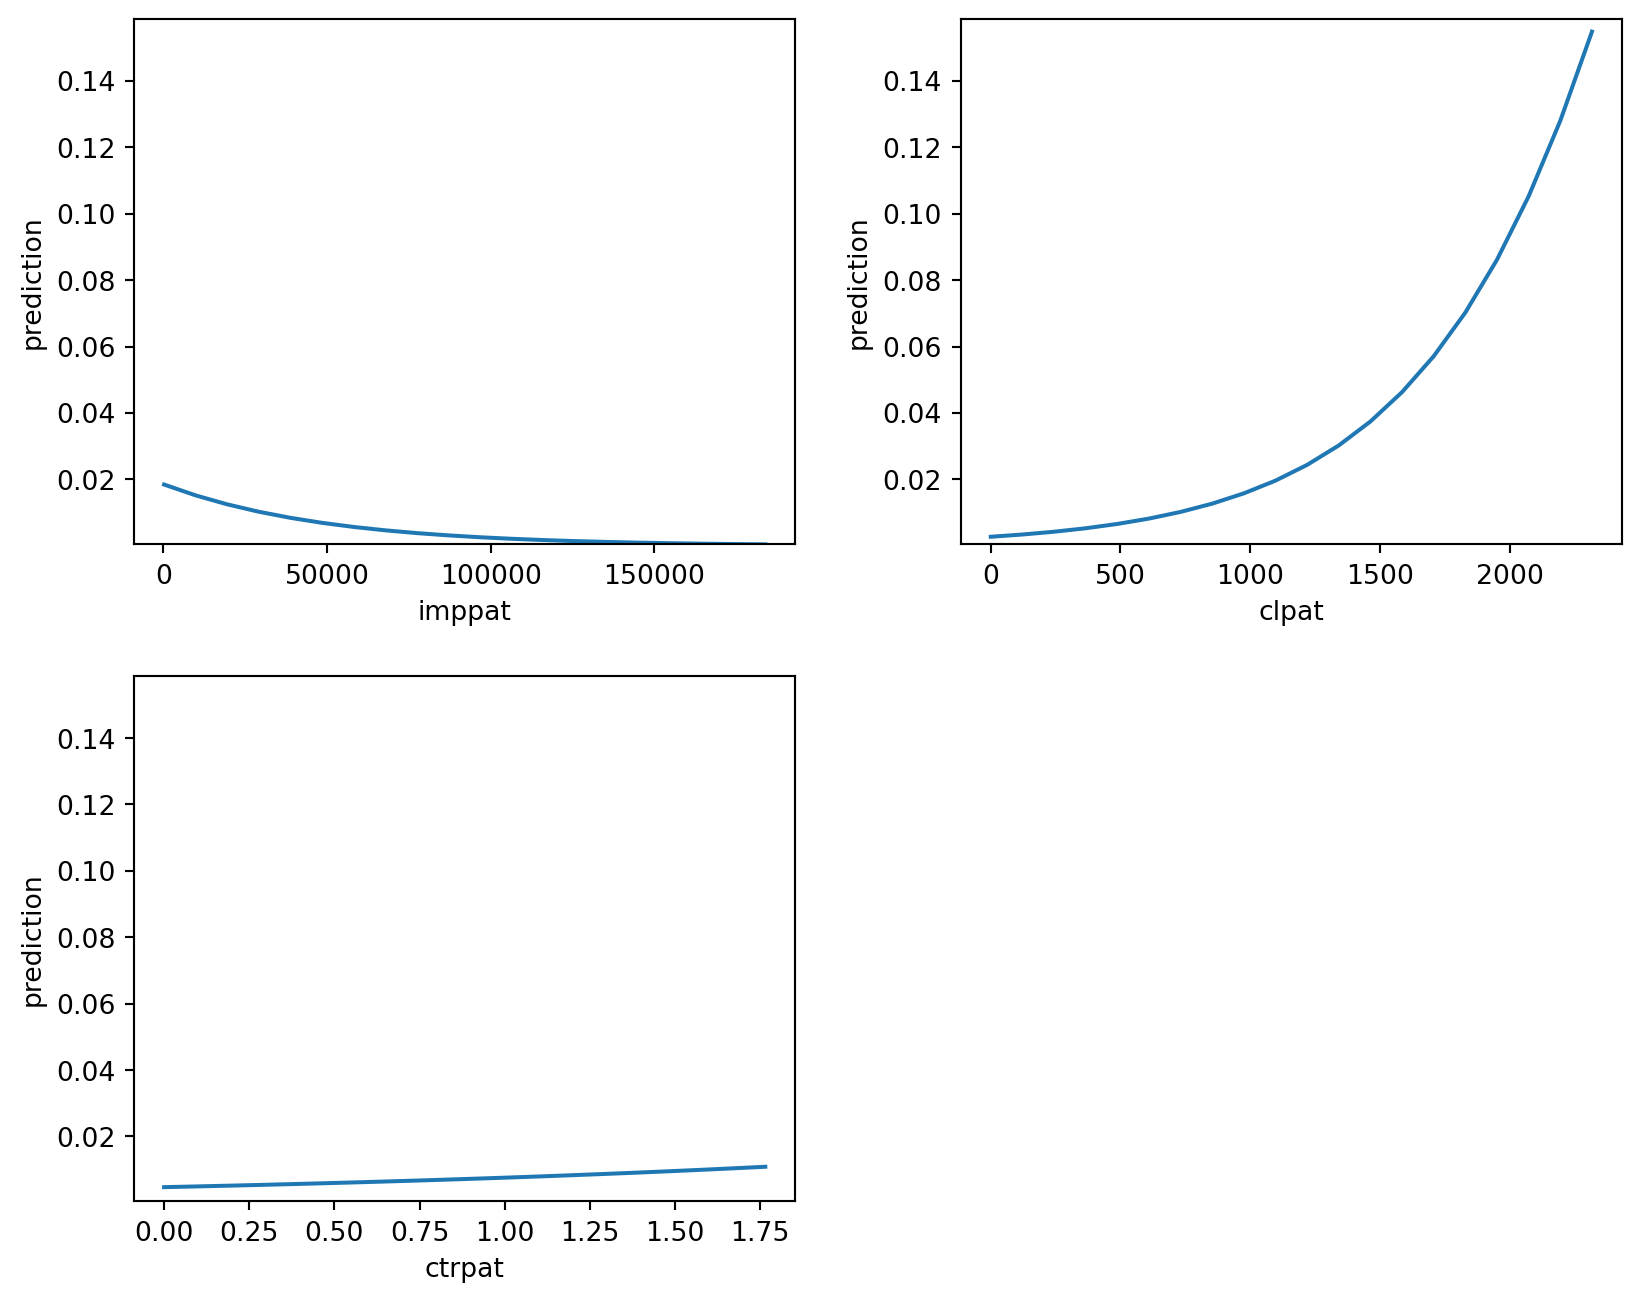

In [30]:
clf_mc1.plot("pred")

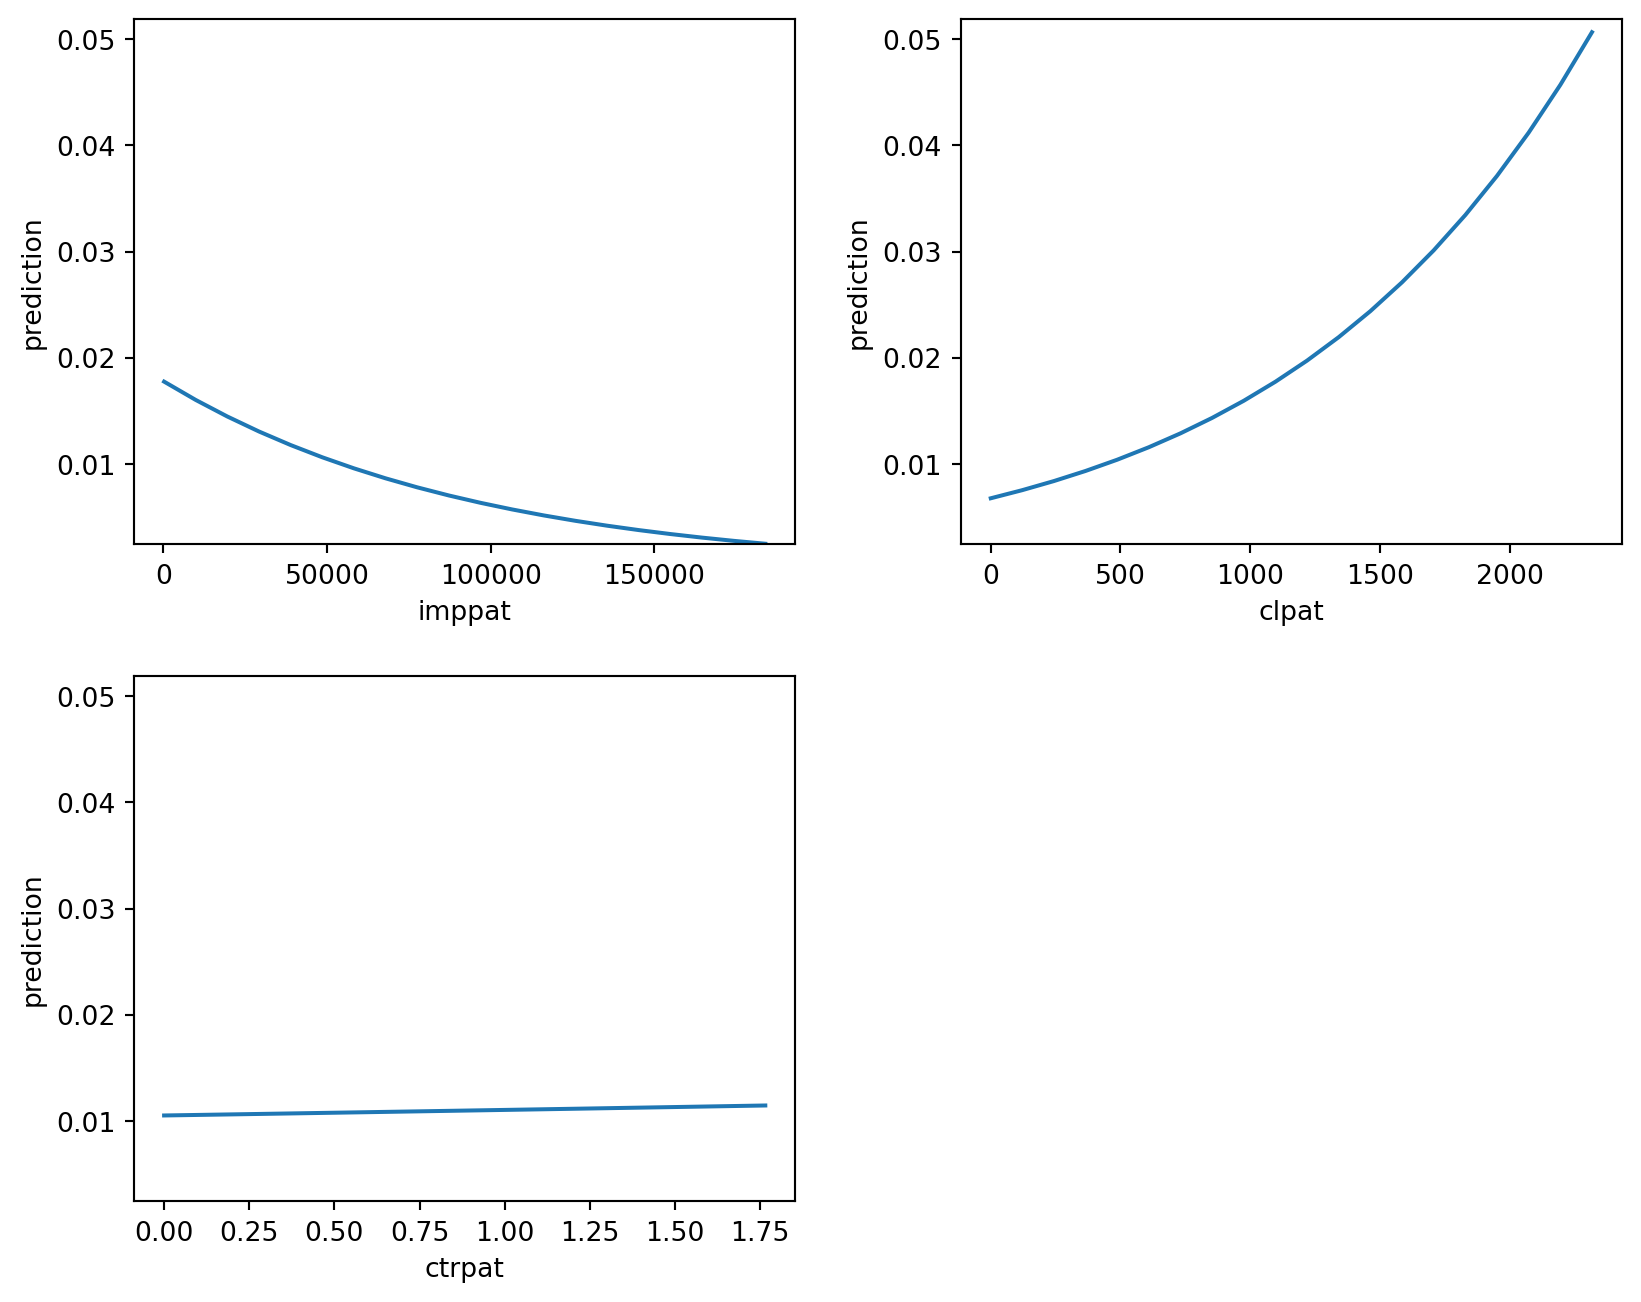

In [31]:
clf_mc3.plot("pred", excl = ["time_fct", "app"])

## Part III: Decile Analysis of Logistic Regression Results (5 points)

> Note: For the following questions, use only the "test" sample of impressions (i.e., 27,953 rows where "training == 'test'")


a. Assign each impression to a decile based on the predicted probability of a click (`pred_logit`) based on the model estimated in I.a. Create a new variable `pred_logit_dec` that captures this information. Note: The first decile should have the highest average click rate. If not, make sure to "reverse" the decile numbers (i.e., 10 becomes 1, 9 becomes 2, etc.). Use the `xtile` function from the `pyrsm` package to create the deciles (2 points)

In [32]:
print(tz_gaming["pred_logit"].isna().sum())  # Check for missing values
print(tz_gaming["pred_logit"].shape[0])         # Check if it's empty

0
115488


In [33]:
tz_gaming["pred_logit_dec"] = (
    tz_gaming
    .groupby("training")
    .pred_logit
    .transform(rsm.xtile, 10, rev = True)
)

In [34]:
dec_tab = (
    tz_gaming[tz_gaming.training == "test"] # should this be test
    .groupby("pred_logit_dec")
    .agg(
        nobs = ("pred_logit", "count"),
        buyer = ("click_yes", "sum"),
        resp_rate = ("click_yes", "mean")
    )
    .reset_index()
)
dec_tab

,pred_logit_dec,nobs,buyer,resp_rate
0,1,2796,103.0,0.036838
1,2,2793,48.0,0.017186
2,3,2788,42.0,0.015065
3,4,2796,30.0,0.010730
4,5,2802,15.0,0.005353
5,6,2796,7.0,0.002504
6,7,2794,7.0,0.002505
7,8,2796,3.0,0.001073
8,9,2796,4.0,0.001431
9,10,2796,12.0,0.004292


b. Report the number of impressions (rows), the number of clicks (`click`), and the click through rate (`ctr`) (i.e., sum of clicks divided by number of impressions) for the TZ ad per decile and save this information to a new dataframe called `dec_tab` (2 points)

In [35]:
# your data frame should have columns called 'nr_impressions', 'nr_clicks', and 'ctr'
# to calculate these values you need deciles, the number of rows (impressions)
# in each decile, the number of clicks in each decile using the `click` variable,
# and the ratio of clicks to impressions (ctr)
dec_tab.columns = ["decile", "nr_impressions", "nr_clicks", "ctr"]
dec_tab

,decile,nr_impressions,nr_clicks,ctr
0,1,2796,103.0,0.036838
1,2,2793,48.0,0.017186
2,3,2788,42.0,0.015065
3,4,2796,30.0,0.010730
4,5,2802,15.0,0.005353
5,6,2796,7.0,0.002504
6,7,2794,7.0,0.002505
7,8,2796,3.0,0.001073
8,9,2796,4.0,0.001431
9,10,2796,12.0,0.004292


c. Create a bar chart of click-through rates per decile (i.e., use `pred_logit_dec` as the x-variable and `ctr` as the y-variable). Note that the "click-through rate" is not the same as the "predicted probability of click." The click-through rate captures the proportion of impressions in a given group (e.g., in a decile) that actually resulted in a click (1 point)

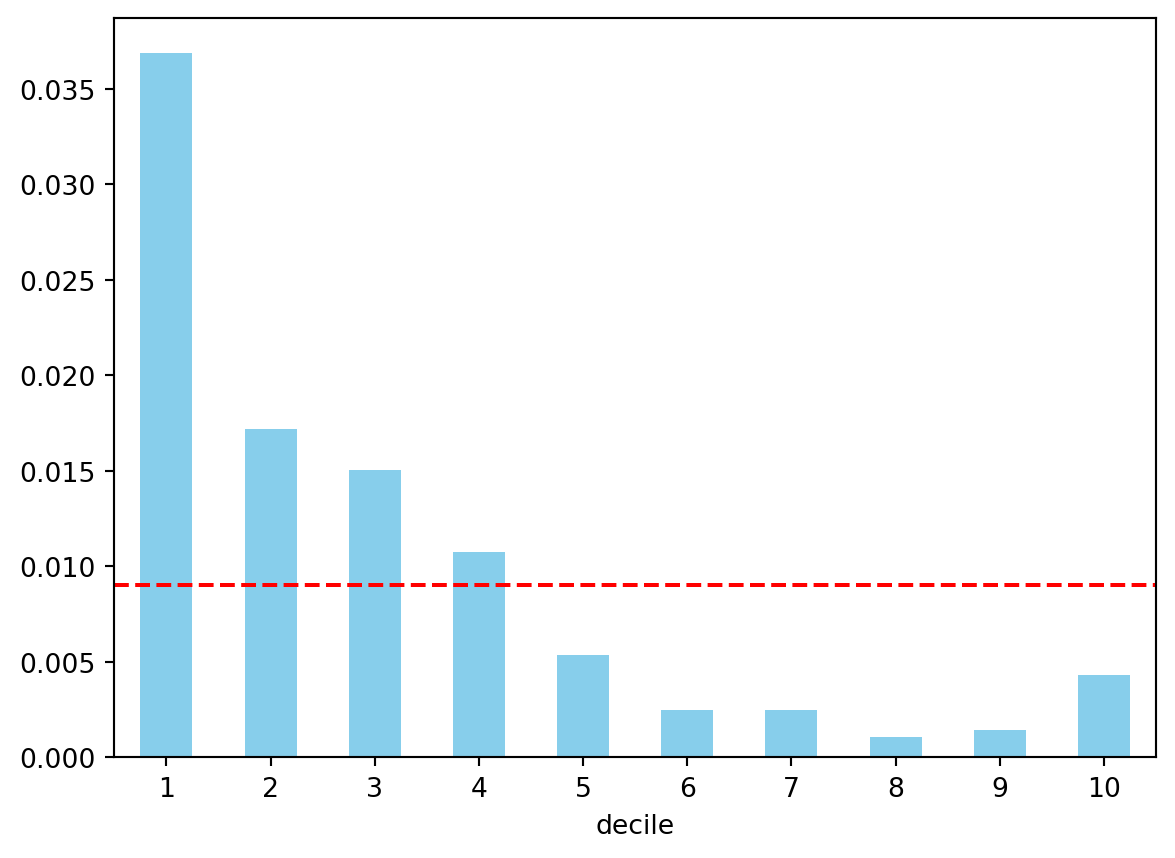

In [36]:
fig = dec_tab.plot.bar(
    x = "decile",
    y = "ctr",
    rot = 0,
    color = "skyblue",
    legend = False
)
fig = fig.axhline(y = tz_gaming.click_yes.mean(), linestyle = "--", color = "red")

## Part IV: Gains Curves (15 points)

Use the `dec_tab` DataFrame you created in Part III for the following calculations.

a. Write python code to generate a table with the cumulative proportion of impressions and the cumulative gains for each decile (8 points)

> Note: Do NOT use any specialized python packages to construct the gains table. Write the python code from scratch. Feel free use ChatGPT or CoPilot, but make sure that it does not use any specialized packages to construct the gains table. Be prepared to discuss the code you submit for this question in class if called upon

In [37]:
# lift calculation
# gains_tab["cum_nr_impressions"] = gains_tab.nr_impressions.cumsum()
# gains_tab["cum_prop_clicks"] = gains_tab.cum_nr_clicks / total
# gains_tab["cum_ctr"] = gains_tab.ctr.cumsum()
# # gains_tab["cum_prop_ctr"] = gains_tab.cum_ctr / total
# total_resp_rate = gains_tab.ctr.sum() 
# print(total_resp_rate)
# gains_tab["lift"] = gains_tab.ctr / total_resp_rate
# gains_tab["cum_lift"] = gains_tab.lift.cumsum()

In [38]:
# make sure you have columns called 'cum_prop' and 'cum_gains'
gains_tab = dec_tab.copy()

gains_tab["cum_prop"] = gains_tab.nr_impressions.cumsum() / gains_tab.nr_impressions.sum()
gains_tab["cum_gains"] = gains_tab.nr_clicks.cumsum() / gains_tab.nr_clicks.sum()

In [39]:
# add row with 0 decile
gains_tab = pd.concat(
    [
        pd.DataFrame(
            {
                "decile": 0,
                "nr_impressions": 0,
                "nr_clicks": 0,
                "ctr": 0,
                "cum_prop": 0,
                "cum_gains": 0
            },
            index = [0]
        ),
        gains_tab
    ]
)

In [40]:
gains_tab

,decile,nr_impressions,nr_clicks,ctr,cum_prop,cum_gains
0,0,0,0.0,0.000000,0.000000,0.000000
0,1,2796,103.0,0.036838,0.100025,0.380074
1,2,2793,48.0,0.017186,0.199943,0.557196
2,3,2788,42.0,0.015065,0.299682,0.712177
3,4,2796,30.0,0.010730,0.399707,0.822878
4,5,2802,15.0,0.005353,0.499946,0.878229
5,6,2796,7.0,0.002504,0.599971,0.904059
6,7,2794,7.0,0.002505,0.699925,0.929889
7,8,2796,3.0,0.001073,0.799950,0.940959
8,9,2796,4.0,0.001431,0.899975,0.955720


b. Use `seaborn`, `matplotlib`, or `pandas` to create a chart showing the cumulative gains per decile along with a (diagonal) reference line to represent the "no model" scenario. Put cumulative gains on the Y-axis and cumulative proportion of impressions on the X-axis (7 points)

> Note: Do NOT use any specialized packages to construct the gains chart. Write the python code from scratch. Feel free use ChatGPT or CoPilot, but make sure that it does not use any specialized packages to construct the gains chart. Be prepared to discuss the code you submit for this question in class if called upon

### using functions for gains and lift tab here

In [41]:
# dec = rsm.calc_qnt(tz_gaming[tz_gaming.training == "test"], "click_yes", "yes", "pred_logit", qnt=10)
# dec
# # using function to calculate deciles

In [42]:
# gains_tab1 = rsm.gains_tab(tz_gaming[tz_gaming.training == "test"], "click_yes", 1, "pred_logit", qnt=10)
# gains_tab1
# # using function to calculate deciles

In [43]:
# lift_tab = rsm.lift_tab(tz_gaming[tz_gaming.training == "test"], "click_yes", 1, "pred_logit", qnt=10)
# lift_tab

In [44]:
# rsm.gains_plot(tz_gaming[tz_gaming.training == "test"], "click_yes", 1,"pred_logit", qnt=10, marker="o")

In [45]:
# rsm.lift_plot(tz_gaming[tz_gaming.training == "test"], "click_yes", 1,"pred_logit", qnt=10, marker="o")

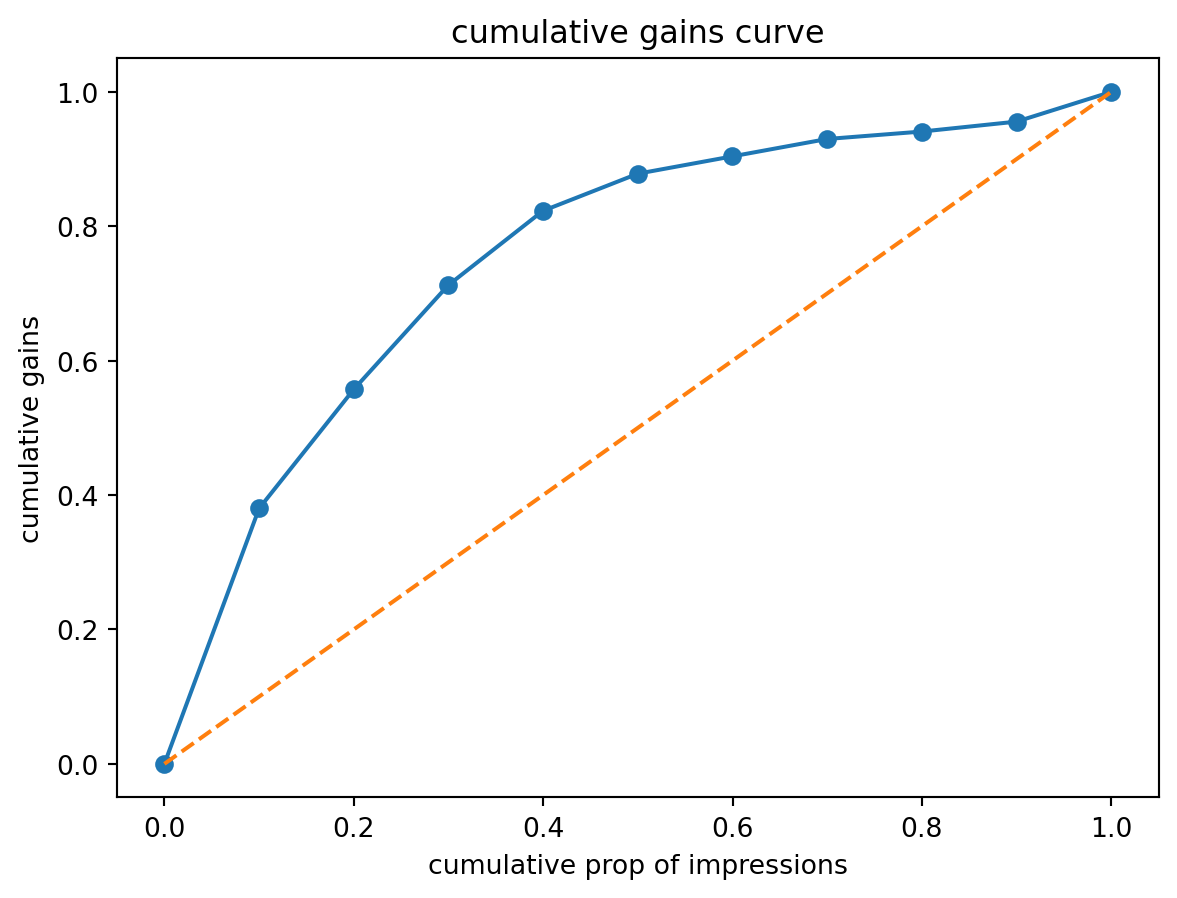

In [46]:
plt.plot(gains_tab.cum_prop, gains_tab.cum_gains, marker = "o", label = "cumulative gains")
plt.plot([0,1], [0,1], linestyle = "--", label = "no model")
plt.xlabel("cumulative prop of impressions")
plt.ylabel("cumulative gains")
plt.title("cumulative gains curve")
plt.show()

## Part V: Confusion matrix (10 points)

a. Create a "confusion matrix" based on the predictions from the logistic regression model you estimated in Part I.a (i.e., the model used to generate `pred_logit`). Again, use **only** data from the test set here (i.e., "training == 'test'"). Use the financial assumptions mentioned above, and repeated in section VI below, to determine an appropriate cut-off (i.e., breakeven). Calculate "accuracy" based on the confusion matrix you created (2 points)

> Note: Do NOT use any specialized packages to construct the confusion matrix. Code the matrix from scratch.  Feel free use ChatGPT or CoPilot, but make sure that it does not use any specialized packages to construct the confusion matrix. Be prepared to discuss the code you submit for this question in class if called upon

> Note use the code format below to store the relevant values from your confusion matrix

ignore cost of data caluculate as if free, see if differences are  big enough to warrant the cost of data
diff current and 50k approach is more than 50k, then worth or not worth

In [47]:
tz_gaming_test = tz_gaming[(tz_gaming.training == "test")]

In [48]:
cpm = 10.0
cpm_cost = cpm / 1000 # float cost per impressions (CPM) # margin per impression

conversion_rate_after_clicking = 0.05 
margin = 25.0 # per converted user # clv

# revenue = 0.05 * 25 * ctr
breakeven = cpm_cost / (conversion_rate_after_clicking * margin) 
# ctr = 0.01 / (conversion_rate_after_clicking * margin)  # click through rate after seeing ad
# print(ctr)
print(breakeven)

0.008


In [49]:
data_cost = 50_000
consulting_cost = 150_000

total_cost = data_cost + consulting_cost

In [50]:
tz_gaming_test['y_pred'] = tz_gaming_test['pred_logit'] > breakeven

/tmp/ipykernel_15781/3161754273.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tz_gaming_test['y_pred'] = tz_gaming_test['pred_logit'] > breakeven


### confusion formula here

In [51]:
# cm = rsm. confusion(tz_gaming_test, "click_yes", 1, "pred_logit", cost=cpm_cost, margin=margin*0.05)
# cm

In [52]:
TP = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred == True)).sum()
FP = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred == True)).sum()
TN = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred == False)).sum()
FN = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred == False)).sum()

In [53]:
cm_logit = pd.DataFrame(
    {
        "label": ["TP", "FP", "TN", "FN"],
        "nr": [TP, FP, TN, FN] # TP, FP, TN, and FN values in that order
    }
)
cm_logit

,label,nr
0,TP,221
1,FP,10661
2,TN,17021
3,FN,50


In [54]:
accuracy_logit = (TP + TN) / (TP + TN + FP + FN) # float 
accuracy_logit

0.6168210925482059

b. Calculate a confusion matrix based on `pred_rnd` created in Part I.e and calculate "accuracy" based on the confusion matrix you created (2 points)

> Note use the code format below to store the relevant values from your confusion matrix

In [55]:
tz_gaming_test["y_pred_rnd"] = tz_gaming_test["pred_rnd"] > breakeven

/tmp/ipykernel_15781/1488838665.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tz_gaming_test["y_pred_rnd"] = tz_gaming_test["pred_rnd"] > breakeven


In [56]:
# cm = rsm. confusion(tz_gaming_test, "click_yes", 1, "pred_rnd", cost=cpm_cost, margin=margin*0.05)
# cm

In [57]:
TP = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_rnd == True)).sum()
FP = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_rnd == True)).sum()
TN = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_rnd == False)).sum()
FN = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_rnd == False)).sum()

In [58]:
cm_rnd = pd.DataFrame(
    {
        "label": ["TP", "FP", "TN", "FN"],
        "nr": [TP, FP, TN, FN] # TP, FP, TN, and FN values in that order
    }
)
cm_rnd

,label,nr
0,TP,271
1,FP,27606
2,TN,76
3,FN,0


In [59]:
accuracy_rnd =  (TP + TN) / (TP + TN + FP + FN) # float
accuracy_rnd

0.012413694415626229

### fucntion to calcuate confsion matrix, accuracru, profit, rome, auc

In [60]:
# rsm.evalbin(tz_gaming_test, "click_yes", 1, "pred_logit", cost=cpm_cost, margin=margin*0.05, scale=1, dec=3)

In [61]:
cm_logit

,label,nr
0,TP,221
1,FP,10661
2,TN,17021
3,FN,50


In [62]:
accuracy_logit

0.6168210925482059

c. Discuss the similarities and differences between the two confusion matrices. Which prediction (model) is best, based on the confusion matrix? Provide support for your conclusions (3 points)

Pred_logit model is the best since is has a accuracy rate of .6168, which is much higher than rnd model at 0.0124. The rnd data is simulated and generated randomly, thus, is not the best to train teh model on as it does not correctly reflect actual behaviors. In terms of the matrices, the rnd model has an almarming amount of false positives, which is giving us inaccurate information. The logit model gives us a higher proportion of true positives and true negatives as oppposed to the incorrectly predicted values false negative and false positive. Something to note also is that rnd matrices has no false negatives, which is very unlikely. This is a sign that the model is not correctly predicting the data.They both predicted similar amounts of true positives, but the logit model has a much higher accuracy rate.

d. Recalculate the confusion matrices from V.a and V.b using 0.5 as the cutoff. Based on these new matrices discuss  the similarities and differences. Which model is best based on these new confusion matrices? Provide support for your conclusions (3 points)

> Note use the code format below to store the relevant values from your confusion matrix

In [63]:
cutoff = 0.05

In [64]:
tz_gaming_test['y_pred_5'] = tz_gaming_test['pred_logit'] > cutoff

/tmp/ipykernel_15781/2920245536.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tz_gaming_test['y_pred_5'] = tz_gaming_test['pred_logit'] > cutoff


In [65]:
TP = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_5 == True)).sum()
FP = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_5 == True)).sum()
TN = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_5 == False)).sum()
FN = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_5 == False)).sum()

In [66]:
cm_logit_recalc = pd.DataFrame(
    {
        "label": ["TP", "FP", "TN", "FN"],
        "nr": [TP, FP, TN, FN]  # TP, FP, TN, and FN values in that order
    }
)
cm_logit_recalc

,label,nr
0,TP,20
1,FP,257
2,TN,27425
3,FN,251


In [67]:
accuracy_logit_recalc = (TP + TN) / (TP + TN + FP + FN) # float
accuracy_logit_recalc

0.9818266375702072

> Note use the code format below to store the relevant values from your confusion matrix

In [68]:
tz_gaming_test['y_pred_rnd_5'] = tz_gaming_test['pred_rnd'] > cutoff

/tmp/ipykernel_15781/3756939366.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tz_gaming_test['y_pred_rnd_5'] = tz_gaming_test['pred_rnd'] > cutoff


In [69]:
TP = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_rnd_5 == True)).sum()
FP = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_rnd_5 == True)).sum()
TN = ((tz_gaming_test.click == "no") & (tz_gaming_test.y_pred_rnd_5 == False)).sum()
FN = ((tz_gaming_test.click == "yes") & (tz_gaming_test.y_pred_rnd_5 == False)).sum()

In [70]:
cm_rnd_recalc = pd.DataFrame(
    {
        "label": ["TP", "FP", "TN", "FN"],
        "nr": [TP, FP, TN, FN]  # TP, FP, TN, and FN values in that order
    }
)
cm_rnd_recalc

,label,nr
0,TP,0
1,FP,0
2,TN,27682
3,FN,271


In [71]:
accuracy_rnd_recalc = (TP + TN) / (TP + TN + FP + FN) # float
accuracy_rnd_recalc

0.9903051550817443

In [72]:
cm_logit_recalc

,label,nr
0,TP,20
1,FP,257
2,TN,27425
3,FN,251


In [73]:
print(accuracy_logit_recalc)
print(accuracy_rnd_recalc)

0.9818266375702072
0.9903051550817443


I would go with the logit model since it provides more well rounded values for the confusion matrix. Despite rnd model having a slightly higher accuracy, the model is raising red flags as there are no true positives and false positives, which is something we'd have ideally. So taking in both models with the confusion matrix and the accuracy, I would go with the logit model. The rnd model is too extreme.

Compared to the previous models with a breakeven of 0.008 instead of 0.5, the logit model had a far higher accuracy than the rnd model. the rnd confusion matrix with the 0.008 breakeven had 0 false negatives, which is also alarming. 

Increasing the breakeven or cutoff to 0.5 is not a good idea as it is an arbitrary value. It is better to use the breakeven value of 0.008 as it is based on the financial assumptions. The accuracy in very high in both the models for the 0.5 cutoff, which means that we have overestimated our performance of the models since the cutoff is so high. We aren't being as picky with who we send it out to due to our prediction of how likely they will click. 

## Part VI: Model comparison (12 points)


Use the following cost information to assess the profitability each of these models for targeting purposes during the upcoming 20-million impression advertising campaign:

* Cost per 1,000 video impressions (CPM) is $10
* Conversion to sign-up as a TZ game player after clicking on an ad is 5%
* The expected CLV of customers that sign-up with TZ after clicking on an ad is approximately $25
* The total cost of the data from Vneta is $50K
* The total cost charged for the data science consulting services by Vneta is $150K

Use `pred_logit`, `pred_rnd`, and the predictions from Vneta based on their proprietary model `pred_vneta` to compare model performance.

> Note: The currently available data (+ the `pred_vneta` prediction) are free of charge as part of the partnership between Vneta and TZ-gaming

a. Create a new variable `target_logit` that is `True` if the predicted click-through (`pred_logit`) probability is greater than the break-even response rate and `FALSE` otherwise (1 point)

In [74]:
tz_gaming["target_logit"] = tz_gaming['pred_logit'] > breakeven

b. Create a new variable `target_rnd` that is `True` if the predicted click-through (`pred_rnd`) probability is greater than the break-even response rate and `FALSE` otherwise (1 point)

In [75]:
tz_gaming["target_rnd"] = tz_gaming['pred_rnd'] > breakeven

c. Create a new variable `target_vneta` that is `True` if the predicted click-through (`pred_vneta`) probability is greater than the break-even response rate and `False` otherwise (1 point)

In [76]:
# insert your answer here
tz_gaming["target_vneta"] = tz_gaming['pred_vneta'] > breakeven
tz_gaming["target_vneta"].value_counts()

target_vneta
False    95530
True     19958
Name: count, dtype: int64

In [77]:
tz_gaming

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,rnd,pred_vneta,id,click_yes,pred_logit,pred_rnd,pred_logit_dec,target_logit,target_rnd,target_vneta
0,train,I7,no,9,9,app8,ios,439,2,0.455581,...,-1.207066,0.003961,id247135,0.0,3.382977e-13,0.009222,10,False,True,False
1,train,I23,no,15,15,app1,ios,64,0,0.000000,...,0.277429,0.003961,id245079,0.0,1.156355e-02,0.008751,3,True,True,False
2,train,I28,no,12,12,app5,ios,80,0,0.000000,...,1.084441,0.003961,id927245,0.0,2.655311e-03,0.008505,7,False,True,False
3,train,I30,no,19,19,app1,ios,25,0,0.000000,...,-2.345698,0.018965,id922188,0.0,1.349420e-02,0.009600,3,True,True,True
4,train,I35,no,24,24,app1,android,3834,29,0.756390,...,0.429125,0.003961,id355833,0.0,1.868222e-03,0.008704,8,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,test,I399982,no,21,21,app2,ios,2110,0,0.000000,...,-1.852059,0.003961,id847352,0.0,1.093091e-03,0.009435,8,False,True,False
115484,test,I399986,no,17,17,app14,android,291,1,0.343643,...,-0.296415,0.003961,id457437,0.0,3.609483e-03,0.008930,6,False,True,False
115485,test,I399991,no,23,23,app1,android,364,3,0.824176,...,0.099201,0.003961,id792352,0.0,2.052670e-02,0.008806,2,True,True,False
115486,test,I399992,no,20,20,app6,android,59,2,3.389831,...,-0.186421,0.050679,id115678,0.0,2.192207e-02,0.008896,1,True,True,True


d. Based on the performance in the test set (i.e, `training == 'test'`), calculate the **projected** expected profit (in dollars) and the expected return on marketing expenditures (ROME) for the upcoming campaign if TZ (1) "spams" everyone, (2) continues to target using their current approach (i.e., use `pred_rnd`), (3) uses the data from Vneta to build the logistic regression from section I (i.e., use `pred_logit`) for targeting, or (4) used Vneta's data science consulting services (i.e., use `pred_vneta`) to **select the best prospects out of 20M impressions**. (3 points)

> Note: Calculate the total **projected profits from selecting the best prospects out of 20M impressions** under the assumption that options (3) and (4) are free of charge. Then compare the profit numbers to determine if these options would be worth the expense going forward.

> Note: Calculate total profits under the assumption that options (3) and (4) are free of charge. Then compare the profit numbers to determine if these options would be worth the expense going forward.

In [78]:
?rsm.evalbin

In [79]:
?rsm.xtile

In [80]:
# calculate and add profit and ROME values for each approach
# to the mod_perf data frame
tz_gaming["pred_spam"] = 1
tz_gaming["target_spam"] = True

In [81]:
tz_gaming_test = tz_gaming[tz_gaming.training == "test"]
tz_gaming_test

,training,inum,click,time,time_fct,app,mobile_os,impup,clup,ctrup,...,id,click_yes,pred_logit,pred_rnd,pred_logit_dec,target_logit,target_rnd,target_vneta,pred_spam,target_spam
87535,test,I300002,no,21,21,app1,android,1458,3,0.205761,...,id466983,0.0,1.020981e-02,0.008791,4,True,True,False,1,True
87536,test,I300006,no,3,3,app40,ios,3,0,0.000000,...,id946375,0.0,8.665095e-03,0.008718,4,True,True,True,1,True
87537,test,I300012,no,5,5,app12,android,5057,6,0.118647,...,id479295,0.0,1.910723e-14,0.008448,10,False,True,False,1,True
87538,test,I300015,no,10,10,app1,android,1993,10,0.501756,...,id83284,0.0,6.240407e-03,0.008630,5,False,True,False,1,True
87539,test,I300016,no,14,14,app1,ios,212,7,3.301887,...,id359434,0.0,1.233449e-02,0.009086,3,True,True,True,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115483,test,I399982,no,21,21,app2,ios,2110,0,0.000000,...,id847352,0.0,1.093091e-03,0.009435,8,False,True,False,1,True
115484,test,I399986,no,17,17,app14,android,291,1,0.343643,...,id457437,0.0,3.609483e-03,0.008930,6,False,True,False,1,True
115485,test,I399991,no,23,23,app1,android,364,3,0.824176,...,id792352,0.0,2.052670e-02,0.008806,2,True,True,False,1,True
115486,test,I399992,no,20,20,app6,android,59,2,3.389831,...,id115678,0.0,2.192207e-02,0.008896,1,True,True,True,1,True


in d scale profits, test set proporation of 20,000,000 scale up

7000/27000 use that ratio to 20M

in f consider full set of 20M inpressions

In [82]:
# # spam everyone
# # eveeryon considered true positive
# nr_message_all = 20_000_000 # total number of messages that would be sent out

# # nr_message_all = tz_gaming_test.pred_spam.count() # total number of messages that would be sent out
# message_cost_all = nr_message_all * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# response_rate_all = (tz_gaming_test.click == "yes").mean()

# nr_responses_all = nr_message_all * response_rate_all # total number of positive responses ????
# revenue_all = 25 * nr_responses_all #* 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_all = revenue_all - message_cost_all # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_all = profit_all / message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)


# # need to add the 5% in somewhere

# print(nr_message_all)
# print(message_cost_all)
# print(response_rate_all)
# print(nr_responses_all)
# print(revenue_all)
# print(f"Profit: {profit_all}")
# print(f"ROME: {ROME_all}")

In [83]:
# # use pred_rnd approach

# tz_gaming_test["message_logit_rnd"] = tz_gaming_test["pred_rnd"] > breakeven

# nr_message_rnd = (tz_gaming_test["message_logit_rnd"] == True).sum() # total number of messages that would be sent out
# message_cost_rnd = nr_message_rnd * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_rnd = ((tz_gaming_test["message_logit_rnd"] == True) & (tz_gaming_test.click == "yes")).mean()
# response_rate_rnd = tz_gaming_test[(tz_gaming_test.click == "yes") & (tz_gaming_test.message_logit_rnd == True)].shape[0] / nr_message_rnd

# # response_rate_rnd = (tz_gaming_test.click == "yes").mean()

# nr_responses_rnd = nr_message_rnd * response_rate_rnd # total number of positive responses ????
# revenue_rnd = 25 * nr_responses_rnd * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_rnd = revenue_rnd - message_cost_rnd # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_rnd = profit_rnd / message_cost_rnd # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere

# print(nr_message_rnd)
# print(message_cost_rnd)
# print(response_rate_rnd)
# print(nr_responses_rnd)
# print(revenue_rnd)
# print(f"Profit: {profit_rnd}")
# print(f"ROME: {ROME_rnd}")

In [84]:
# # use pred_logit

# tz_gaming_test["message_logit"] = tz_gaming_test["pred_logit"] > breakeven

# nr_message_log = (tz_gaming_test["message_logit"] == True).sum() # total number of messages that would be sent out
# message_cost_log = nr_message_log * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_log = ((tz_gaming_test["message_logit"] == True) & (tz_gaming_test.click == "yes")).mean()
# response_rate_log = tz_gaming_test[(tz_gaming_test.click == "yes") & (tz_gaming_test.message_logit == True)].shape[0] / nr_message_log

# # response_rate_log = (tz_gaming_test.click == "yes").mean()

# nr_responses_log = nr_message_log * response_rate_log # total number of positive responses ????
# revenue_log = 25 * nr_responses_log * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_log = revenue_log - message_cost_log # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_log = profit_log / message_cost_log # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere

# print(nr_message_log)
# print(message_cost_log)
# print(response_rate_log)
# print(nr_responses_log)
# print(revenue_log)
# print(f"Profit: {profit_log}")
# print(f"ROME: {ROME_log}")

In [85]:
# # use vneta consulting use pred_vneta

# tz_gaming_test["message_vneta"] = tz_gaming_test["pred_vneta"] > breakeven

# nr_message_vneta = (tz_gaming_test["message_vneta"] == True).sum() # total number of messages that would be sent out
# message_cost_vneta = nr_message_vneta * 0.01 # total cost of sending messages to selected customers (float) 

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_vneta = ((tz_gaming_test["message_vneta"] == True) & (tz_gaming_test.click == "yes")).mean()

# response_rate_vneta = tz_gaming_test[(tz_gaming_test.click == "yes") & (tz_gaming_test.message_vneta == True)].shape[0] / nr_message_vneta

# # response_rate_vneta = (tz_gaming_test.click == "yes").mean()

# nr_responses_vneta = nr_message_vneta * response_rate_vneta # total number of positive responses ????
# revenue_vneta = 25 * nr_responses_vneta * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_vneta = revenue_vneta - message_cost_vneta # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_vneta = profit_vneta / message_cost_vneta # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere
 
# print(nr_message_vneta)
# print(message_cost_vneta)
# print(response_rate_vneta)
# print(nr_responses_vneta)
# print(revenue_vneta)
# print(f"Profit: {profit_vneta}")
# print(f"ROME: {ROME_vneta}")

In [86]:
# spam

exp_click = 20_000_000 * (tz_gaming_test.click == "yes").mean()
exp_signup = exp_click * 0.05
exp_rev = exp_signup * 25

marketing_cost = 20_000_000 * 0.01
profit_all = exp_rev - marketing_cost
ROME_all = profit_all / marketing_cost

print(exp_click)
print(exp_signup)
print(exp_rev)
print(marketing_cost)
print(f"Profit: {profit_all}")
print(f"ROME: {ROME_all}")

193896.89836511287
9694.844918255643
242371.12295639107
200000.0
Profit: 42371.122956391075
ROME: 0.2118556147819554


In [87]:
cm_logit

,label,nr
0,TP,221
1,FP,10661
2,TN,17021
3,FN,50


In [88]:
# logit
exp_click_log = 20_000_000 * (221/27953)
exp_signup_log = exp_click_log * 0.05
exp_rev_log = exp_signup_log * 25

marketing_cost_log = ((20_000_000 * (221/27953)) + (20_000_000 * (10661/27953))) * 0.01
profit_log = exp_rev_log - marketing_cost_log
ROME_log = profit_log / marketing_cost_log

print(exp_click_log)
print(exp_signup_log)
print(exp_rev_log)
print(marketing_cost_log)
print(f"Profit: {profit_log}")
print(f"ROME: {ROME_log}")

158122.5628733946
7906.128143669731
197653.20359174328
77859.26376417557
Profit: 119793.93982756771
ROME: 1.5385958463517737


In [89]:
# rnd

exp_click_rnd = 20_000_000 * (271/27953)
exp_signup_rnd = exp_click_rnd * 0.05
exp_rev_rnd = exp_signup_rnd * 25

marketing_cost_rnd = ((20_000_000 * (271/27953)) + (20_000_000 * (27606/27953))) * 0.01
profit_rnd = exp_rev_rnd - marketing_cost_rnd
ROME_rnd = profit_rnd / marketing_cost_rnd

print(exp_click_rnd)
print(exp_signup_rnd)
print(exp_rev_rnd)
print(marketing_cost_rnd)
print(f"Profit: {profit_rnd}")
print(f"ROME: {ROME_rnd}")

193896.89836511287
9694.844918255643
242371.12295639107
199456.2301005259
Profit: 42914.89285586518
ROME: 0.21515945044301743


In [90]:
TP = ((tz_gaming_test.click == "yes") & (tz_gaming_test.target_vneta == True)).sum()
FP = ((tz_gaming_test.click == "no") & (tz_gaming_test.target_vneta == True)).sum()
TN = ((tz_gaming_test.click == "no") & (tz_gaming_test.target_vneta == False)).sum()
FN = ((tz_gaming_test.click == "yes") & (tz_gaming_test.target_vneta == False)).sum()

cm_vndeta = pd.DataFrame(
    {
        "label": ["TP", "FP", "TN", "FN"],
        "nr": [TP, FP, TN, FN]  # TP, FP, TN, and FN values in that order
    }
)
cm_vndeta

,label,nr
0,TP,160
1,FP,4711
2,TN,22971
3,FN,111


In [91]:
# vndeta

exp_click_v = 20_000_000 * (160/27953)
exp_signup_v = exp_click_v * 0.05
exp_rev_v = exp_signup_v * 25

marketing_cost_v = ((20_000_000 * (160/27953)) + (20_000_000 * (4711/27953))) * 0.01
profit_vneta = exp_rev_v - marketing_cost_v
ROME_vneta = profit_vneta / marketing_cost_v

print(exp_click_rnd)
print(exp_signup_rnd)
print(exp_rev_rnd)
print(marketing_cost_rnd)
print(f"Profit: {profit_vneta}")
print(f"ROME: {ROME_vneta}")

193896.89836511287
9694.844918255643
242371.12295639107
199456.2301005259
Profit: 108245.98433084103
ROME: 3.1059330732909047


In [92]:
mod_perf = pd.DataFrame(
    {
        "model": [
            "logit",
            "rnd",
            "vneta",
            "spam",
        ],
        "profit": [profit_log, profit_rnd, profit_vneta, profit_all],
        "ROME": [ROME_log, ROME_rnd, ROME_vneta, ROME_all],
    }
)
mod_perf

,model,profit,ROME
0,logit,119793.939828,1.538596
1,rnd,42914.892856,0.215159
2,vneta,108245.984331,3.105933
3,spam,42371.122956,0.211856


e. Based on the projected profit numbers from VI.d, discuss which of these 4 approaches you would recommend and why (2 points)

Logit and vnets has the highest profit and are close to each other, but once you factor in the cost of the data, profit for logit would be 69793 and vneta would be in the negaties - 41755. The vnedta model is too costly for the revenue it generates. It does not even break even. so the data is not worth the extra cost. Spam is the base line and worst case scenario, so I would not choose that. Additionally, all models should have a higher profit that spam. the rnd model is slightly better than spam, but not by much. After considering the costs, I would choose the logit model as it has the highest profit. If you recalculate the ROME after the costs, logit will also have the highest ROME. The logit model will be the best option for TZ gaming to use for their ad campaign.

f. Calculate the profit and ROME implications for each of the 4 options mentioned in VI.d if TZ purchases exactly 20-million impressions for the upcoming ad campaign out of the +500M prospects that Vneta has access to (2 points)

> Note: Calculate **projected profits from purchasing exactly 20M impressions** under the assumption that options (3) and (4) are free of charge. Then compare the profit numbers to determine if these options would be worth the expense going forward.

> Note: For efficiency, consider adapting the `perf_calc` function you created for the Tuango case to do the relevant performance calculations for the different models.

In [93]:
# # spam approach

# nr_message_all = tz_gaming.pred_spam.count()  # total number of messages that would be sent out
# message_cost_all = nr_message_all * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# response_rate_all = (tz_gaming.click == "yes").mean()

# nr_responses_all = nr_message_all * response_rate_all # total number of positive responses ????
# revenue_all = 25 * nr_responses_all * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_all = revenue_all - message_cost_all # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_all = profit_all / message_cost_all # Return on Marketing Expenditures expressed as a proportion (no rounding)


# # need to add the 5% in somewhere

# print(nr_message_all)
# print(message_cost_all)
# print(response_rate_all)
# print(nr_responses_all)
# print(revenue_all)
# print(f"Profit: {profit_all}")
# print(f"ROME: {ROME_all}")

In [94]:
# # use pred_rnd approach

# tz_gaming["message_logit_rnd"] = tz_gaming["pred_rnd"] > breakeven

# nr_message_rnd = (tz_gaming["message_logit_rnd"] == True).sum() # total number of messages that would be sent out
# message_cost_rnd = nr_message_rnd * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_rnd = ((tz_gaming["message_logit_rnd"] == True) & (tz_gaming.click == "yes")).mean()
# response_rate_rnd = tz_gaming[(tz_gaming.click == "yes") & (tz_gaming.message_logit_rnd == True)].shape[0] / nr_message_rnd

# # response_rate_rnd = (tz_gaming.click == "yes").mean()

# nr_responses_rnd = nr_message_rnd * response_rate_rnd # total number of positive responses ????
# revenue_rnd = 25 * nr_responses_rnd * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_rnd = revenue_rnd - message_cost_rnd # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_rnd = profit_rnd / message_cost_rnd # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere

# print(nr_message_rnd)
# print(message_cost_rnd)
# print(response_rate_rnd)
# print(nr_responses_rnd)
# print(revenue_rnd)
# print(f"Profit: {profit_rnd}")
# print(f"ROME: {ROME_rnd}")

In [95]:
# # use data from vneta model section 1 use pred_logit

# tz_gaming["message_logit"] = tz_gaming["pred_logit"] > breakeven

# nr_message_log = (tz_gaming["message_logit"] == True).sum() # total number of messages that would be sent out
# message_cost_log = nr_message_log * 0.01 # total cost of sending messages to selected customers (float)

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_log = ((tz_gaming["message_logit"] == True) & (tz_gaming.click == "yes")).mean()
# response_rate_log = tz_gaming[(tz_gaming.click == "yes") & (tz_gaming.message_logit == True)].shape[0] / nr_message_log

# # response_rate_log = (tz_gaming.click == "yes").mean()

# nr_responses_log = nr_message_log * response_rate_log # total number of positive responses ????
# revenue_log = 25 * nr_responses_log * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_log = revenue_log - message_cost_log # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_log = profit_log / message_cost_log # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere

# print(nr_message_log)
# print(message_cost_log)
# print(response_rate_log)
# print(nr_responses_log)
# print(revenue_log)
# print(f"Profit: {profit_log}")
# print(f"ROME: {ROME_log}")

In [96]:
# # use vneta consulting use pred_vneta

# tz_gaming["message_vneta"] = tz_gaming["pred_vneta"] > breakeven

# nr_message_vneta = (tz_gaming["message_vneta"] == True).sum() # total number of messages that would be sent out
# message_cost_vneta = nr_message_vneta * 0.01 # total cost of sending messages to selected customers (float) 

# # response_rate_all = all.loc["yes", "perc"] # or is it the 5% # expressed as a proportion (no rounding)
# # response_rate_vneta = ((tz_gaming["message_vneta"] == True) & (tz_gaming.click == "yes")).mean()
# response_rate_vneta = tz_gaming[(tz_gaming.click == "yes") & (tz_gaming.message_vneta == True)].shape[0] / nr_message_vneta

# # response_rate_vneta = (tz_gaming.click == "yes").mean()

# nr_responses_vneta = nr_message_vneta * response_rate_vneta # total number of positive responses ????
# revenue_vneta = 25 * nr_responses_vneta * 0.05 # avg_ordersize * # total revenue in RMB (no rounding)      ??? is 5% here ok?
# profit_vneta = revenue_vneta - message_cost_vneta # 0.5 * revenue - message_cost - total profit in RMB (no rounding)
# ROME_vneta = profit_vneta / message_cost_vneta # Return on Marketing Expenditures expressed as a proportion (no rounding)

# # need to add the 5% in somewhere
 
# print(nr_message_vneta)
# print(message_cost_vneta)
# print(response_rate_vneta)
# print(nr_responses_vneta)
# print(revenue_vneta)
# print(f"Profit: {profit_vneta}")
# print(f"ROME: {ROME_vneta}")

In [97]:
# spam

exp_click = 20_000_000 * (tz_gaming_test.click == "yes").mean()
exp_signup = exp_click * 0.05
exp_rev = exp_signup * 25

marketing_cost = 20_000_000 * 0.01
profit_all = exp_rev - marketing_cost
ROME_all = profit_all / marketing_cost

print(exp_click)
print(exp_signup)
print(exp_rev)
print(marketing_cost)
print(f"Profit: {profit_all}")
print(f"ROME: {ROME_all}")

193896.89836511287
9694.844918255643
242371.12295639107
200000.0
Profit: 42371.122956391075
ROME: 0.2118556147819554


In [98]:
# logit

total = (tz_gaming_test['target_logit'] == True).sum()
clicks = ((tz_gaming_test.click == 'yes') & (tz_gaming_test.target_logit == True)).sum()

print(total)
print(clicks)

exp_click_log = 20_000_000 * (clicks/total)
exp_signup_log = exp_click_log * 0.05
exp_rev_log = exp_signup_log * 25

marketing_cost_log = 20_000_000 * 0.01
profit_log = exp_rev_log - marketing_cost_log
ROME_log = profit_log / marketing_cost_log
print(total)
print(clicks)

print(exp_click_log)
print(exp_signup_log)
print(exp_rev_log)
print(marketing_cost_log)
print(f"Profit: {profit_log}")
print(f"ROME: {ROME_log}")

10882
221
10882
221
406175.3354162838
20308.766770814193
507719.1692703548
200000.0
Profit: 307719.1692703548
ROME: 1.538595846351774


In [99]:
# rnd
total_rnd = (tz_gaming_test['target_rnd'] == True).sum()
clicks_rnd = ((tz_gaming_test.click == 'yes') & (tz_gaming_test.target_rnd == True)).sum()

exp_click_rnd = 20_000_000 * (clicks_rnd/total_rnd)
exp_signup_rnd = exp_click_rnd * 0.05
exp_rev_rnd = exp_signup_rnd * 25

# 20M times the ratio of TP. The ratio of TP is the ratio of the numbers that "((tz_test['click'] == 'yes') & (tz_test['target_logit'] == True))" divided by "tz_test['target_logit'] == True"

marketing_cost_rnd = 20_000_000 * 0.01
profit_rnd = exp_rev_rnd - marketing_cost_rnd
ROME_rnd = profit_rnd / marketing_cost_rnd

print(exp_click_rnd)
print(exp_signup_rnd)
print(exp_rev_rnd)
print(marketing_cost_rnd)
print(f"Profit: {profit_rnd}")
print(f"ROME: {ROME_rnd}")

194425.5120708828
9721.27560354414
243031.89008860348
200000.0
Profit: 43031.89008860348
ROME: 0.2151594504430174


In [100]:
# vneta

total_v = (tz_gaming_test['target_vneta'] == True).sum()
clicks_v = ((tz_gaming_test.click == 'yes') & (tz_gaming_test.target_vneta == True)).sum()


exp_click_v = 20_000_000 * (clicks_v/total_v)
exp_signup_v = exp_click_v * 0.05
exp_rev_v = exp_signup_v * 25

marketing_cost_v = 20_000_000 * 0.01
profit_vneta = exp_rev_v - marketing_cost_v
ROME_vneta = profit_vneta / marketing_cost_v

print(exp_click_v)
print(exp_signup_v)
print(exp_rev_v)
print(marketing_cost_v)
print(f"Profit: {profit_vneta}")
print(f"ROME: {ROME_vneta}")

656949.2917265448
32847.464586327245
821186.6146581811
200000.0
Profit: 621186.6146581811
ROME: 3.1059330732909056


In [101]:
mod_perf_20M = pd.DataFrame(
    {
        "model": [
            "logit",
            "rnd",
            "vneta",
            "spam",
        ],
        "profit": [profit_log, profit_rnd, profit_vneta, profit_all],
        "ROME": [ROME_log, ROME_rnd, ROME_vneta, ROME_all],
    }
)
mod_perf_20M

,model,profit,ROME
0,logit,307719.169270,1.538596
1,rnd,43031.890089,0.215159
2,vneta,621186.614658,3.105933
3,spam,42371.122956,0.211856


In [102]:
profit_log_end = profit_log - 50_000
ROME_log_end = profit_log_end / (marketing_cost_log - 50_000)

print(f"Profit: {profit_log_end}")
print(f"ROME: {ROME_log_end}")

Profit: 257719.1692703548
ROME: 1.7181277951356986


In [103]:
profit_vneta_end = profit_vneta - 150_000
ROME_vneta_end = profit_vneta_end / (marketing_cost_v - 150_000)

print(f"Profit: {profit_vneta_end}")
print(f"ROME: {ROME_vneta_end}")

Profit: 471186.6146581811
ROME: 9.423732293163622


g. Based on the results from VI.f, discuss which of the 4 approaches you would recommend to put into production and why. Is your recommendation different from VI.e? Why (not) (2 points)

Spam would be the worst approach to choose as it is the baseline and has the lowest profit. We are blindly sending it out to everyone. The rnd model is slightly better than spam, but not by much. After factoring the costs for logit an vneta, logit will have 257719 in profit with rome of 1.7 and vneta will have 471186 in profit with rome of 9.4. With that being said, I would choose vneta as it has the highest profit and ROME. The $150k consulting cost is worth the additional profit that it will bring in. My recommendation is different from VI.e as profit levels have changed. vneta makes more money here than it did in VI.e, where it did not even break even. Logit is no longer the best option. The vneta model is the best option to choose for TZ gaming.


## Part VII: Generative AI (5 points)

Please describe how you used Generative AI-tools like ChatGPT to support your work on this assignment and enhance your learning. Create a pdf where you organize your interactions with AI and comment on what things did and did not go well. Bring any questions you may have about the assignment and the support you received from GenAI to class so we can discuss.

Make sure to include:

- Specific examples of prompts you used
- How the AI responses helped or hindered your understanding
- Any limitations or challenges you encountered
- Key insights gained from using GenAI tools
- Questions that arose during your interactions with AI
- How GenAI complemented your learning process

Note: No matter how you used Generative AI-tools, you will be expected to understand and talk meaningfully about the work you submitted for this assignment. You may be called on in class to walk us through your thought process and calculations.

[141.08997326]


<Axes: xlabel='Percentage of population targeted', ylabel='Expected Profit'>

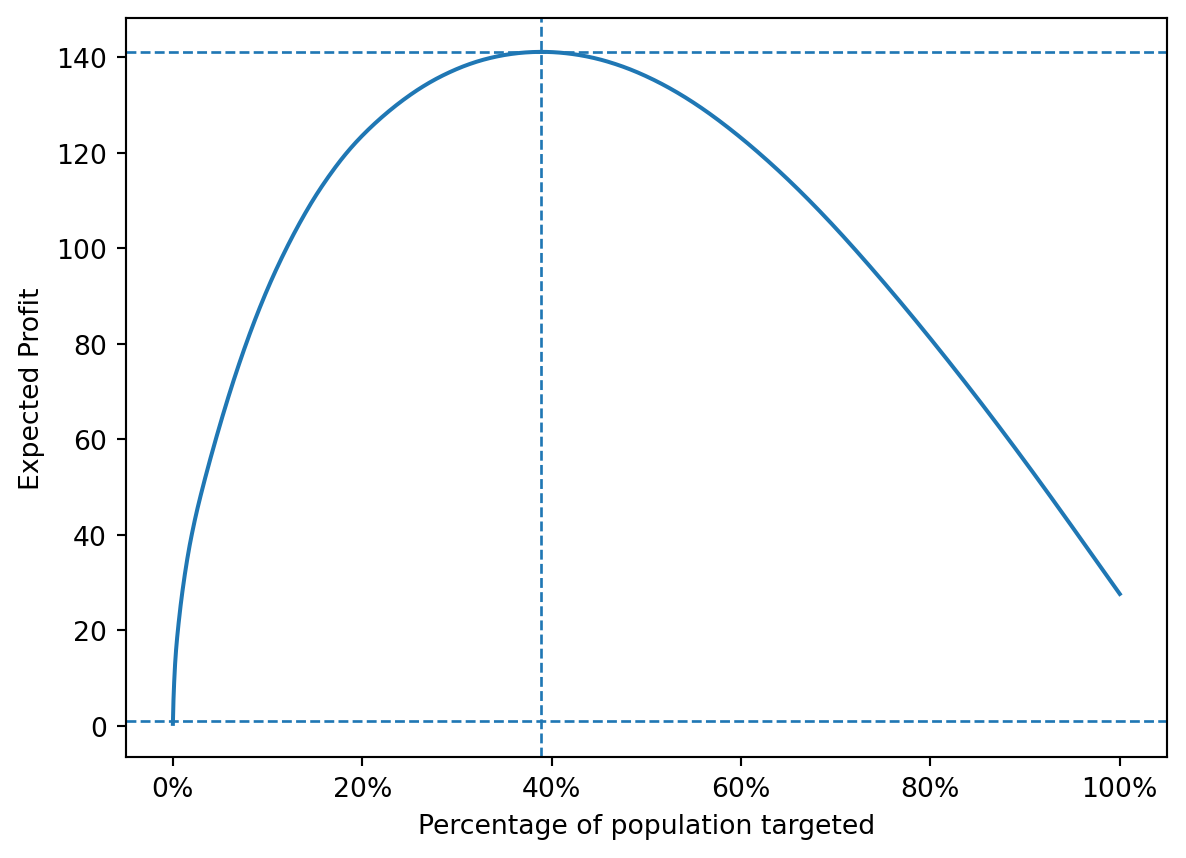

In [104]:
rsm.expected_profit_plot(
    tz_gaming_test, "click_yes", 1, "pred_logit", cost=cpm_cost, margin=margin*0.05, scale=1, contact=True, prn=True
)

In [105]:
# rsm.profit_plot(
#     tz_gaming_test,
#     "click_yes",
#     1,
#     "pred_logit",
#     qnt=10,
#     cost=cpm_cost,
#     margin=margin*0.05,
#     scale=1,
#     contact=True,
#     marker="o",
#     prn=True,
# )

<Axes: xlabel='Percentage of population targeted', ylabel='Return on Marketing Expenditures (ROME)'>

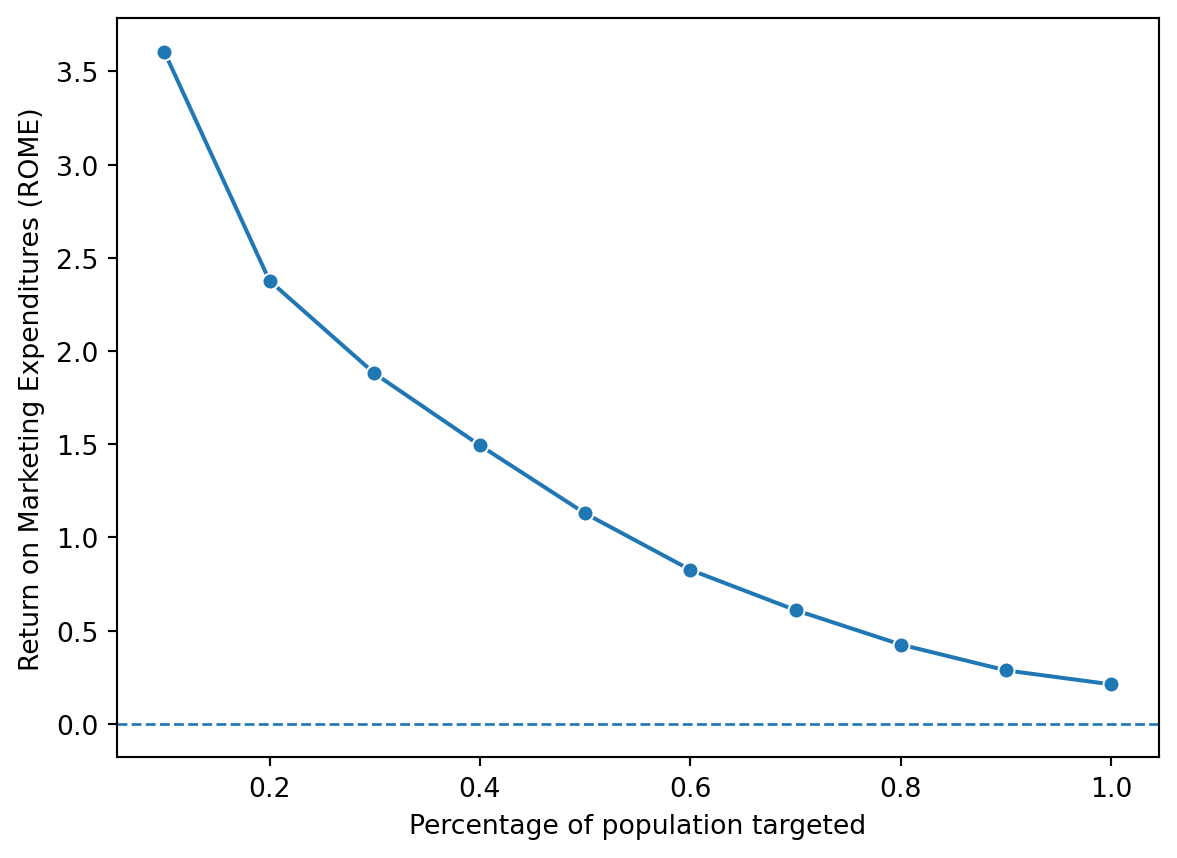

In [106]:
rsm.ROME_plot(tz_gaming_test, "click_yes", 1, "pred_logit", qnt=10, cost=cpm_cost, margin=margin*0.05, marker="o")